# Data-Shaping Program

## 1. Spliting Train and Test Dataset

This part mainly coded by GPT, adjusted by author.

In [1]:
import os
import shutil
import numpy as np

import os
import random
import shutil
from sklearn.model_selection import train_test_split

def stratified_split_folders(
    input_root,
    output_train,
    output_test,
    test_size=0.2,
    min_samples=2,
    verbose=True
):
    

    os.makedirs(output_train, exist_ok=True)
    os.makedirs(output_test, exist_ok=True)

    # 一级目录 = 类别名
    class_dirs = [
        d for d in os.listdir(input_root)
        if os.path.isdir(os.path.join(input_root, d))
    ]

    for cls in class_dirs:
        class_path = os.path.join(input_root, cls)

        # 第二级目录 = 一个 SN（多个光谱文件的集合）
        objects = [
            d for d in os.listdir(class_path)
            if os.path.isdir(os.path.join(class_path, d))
        ]

        if len(objects) < min_samples:
            if verbose:
                print(f"Class {cls} Only {len(objects)} objects!")
            continue

        # 进行分层抽样
        train_objs, test_objs = train_test_split(
            objects,
            test_size=test_size,
            random_state=42
        )

        if verbose:
            print(f"\n Classes: {cls}")
            print(f"  - Train_num: {len(train_objs)}")
            print(f"  - Test_num: {len(test_objs)}")

        # 创建输出目录
        train_class_dir = os.path.join(output_train, cls)
        test_class_dir = os.path.join(output_test, cls)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        # --- 复制 Train ---
        for obj in train_objs:
            src = os.path.join(class_path, obj)
            dst = os.path.join(train_class_dir, obj)
            shutil.copytree(src, dst)

        # --- 复制 Test ---
        for obj in test_objs:
            src = os.path.join(class_path, obj)
            dst = os.path.join(test_class_dir, obj)
            shutil.copytree(src, dst)


    print(f"Train set Saved: {output_train}")
    print(f"Test set Saved : {output_test}")




    
def _read_spectrum_file(filepath, delimiter=None, try_fits=True):
    
   
    try:
        data = np.genfromtxt(filepath, comments='#', delimiter=delimiter, invalid_raise=False,skip_header=1)
        if data is None:
            raise ValueError("genfromtxt return None")
        data = np.atleast_2d(data)
    except Exception:
       
        if try_fits and filepath.lower().endswith(('.fit', '.fits')):
            try:
                from astropy.io import fits
                with fits.open(filepath, memmap=False) as hdul:
                    
                    for hdu in hdul:
                        if hasattr(hdu, 'data') and hdu.data is not None:
                            arr = hdu.data
                           
                            if getattr(arr, 'dtype', None) is not None and arr.dtype.names is not None:
                                
                                names = arr.dtype.names
                                if 'loglam' in names and 'flux' in names:
                                    wave = 10**arr['loglam'].astype(float)
                                    flux = arr['flux'].astype(float)
                                    err = (arr['ivar'].astype(float)**-0.5) if 'ivar' in names else None
                                    return wave, flux, err
                                else:
                                   
                                    vals = [arr[name].astype(float) for name in names[:min(3, len(names))]]
                                    data = np.vstack(vals).T
                                    break
                            else:
                               
                                data = np.array(arr)
                                break
                    else:
                        raise IOError("FITS no data!")
            except Exception as ef:
                raise IOError(f"FITS can't read by astropy: {ef}")
        else:
            raise IOError(f"TXT file can't read by astropy: {filepath}")

    
    if data.ndim == 1:
        
        raise IOError(f"read {filepath} get 1 line data， at least 2 is expected.")
    ncols = data.shape[1]
    if ncols == 2:
        wave = data[:, 0].astype(float)
        flux = data[:, 1].astype(float)
        err = None
    elif ncols == 3:
        wave = data[:, 0].astype(float)
        flux = data[:, 1].astype(float)
        err = data[:, 2].astype(float)
    else:
       
        wave = data[:, 0].astype(float)
        flux = data[:, 1].astype(float)
        err = None
    return wave, flux, err

def process_second_level_dirs(
    top_dir,
    target_dir,
    overlay=True,
    max_files=None,
    plot_errbars=True,
    file_exts=None,
    delimiter=None,
    try_fits=False,
    verbose=True
):
    
    os.makedirs(target_dir, exist_ok=True)

    second_level_dirs = [os.path.join(top_dir, d) for d in os.listdir(top_dir)
                         if os.path.isdir(os.path.join(top_dir, d))]
    if len(second_level_dirs) == 0:
        if verbose: print("Trunck root has no leaf")
        return

    def _match_ext(fp):
        if file_exts is None:
            return True
        return any(fp.lower().endswith(ext.lower()) for ext in file_exts)

    for sec_dir in second_level_dirs:
        
        
        sec_name = os.path.basename(sec_dir)
        
        if sec_name=='z_adjust' or sec_name=='Galaxy':
            continue
            
        sec_target_dir = os.path.join(target_dir, sec_name)
        os.makedirs(sec_target_dir, exist_ok=True)

        if verbose: print(f"\n processing: {sec_dir}")

       
        for third_dir in [os.path.join(sec_dir, d) for d in os.listdir(sec_dir)
                          if os.path.isdir(os.path.join(sec_dir, d))]:
            redshift = 0.0
            csv_path = os.path.join(third_dir, "wiserep_spectra.csv")
            #print(csv_path)
            
                
            df = pd.read_csv(csv_path)
               
            redshift = float(df["Redshift"].iloc[0])
            print(redshift)
                
                    
                    

            
            files = []
            for fn in os.listdir(third_dir):
                fp = os.path.join(third_dir, fn)
                if os.path.isfile(fp) and _match_ext(fn):
                    files.append(fp)

            if len(files) == 0:
                if verbose: print(f"Root {third_dir} has no file")
                continue

            if max_files is not None:
                files = files[:max_files]

          
            if overlay:
                plt.figure(figsize=(10, 6))

            for fp in files:
                try:
                    wave, flux, err = _read_spectrum_file(fp, delimiter=delimiter, try_fits=try_fits)
                    wave, flux = np.asarray(wave).ravel(), np.asarray(flux).ravel()
                    mask = np.isfinite(wave) & np.isfinite(flux)
                    if mask.sum() < 2:
                        if verbose: print(f"skip {fp}")
                        continue
                    wave, flux = wave[mask], flux[mask]
                    sort_idx = np.argsort(wave)
                    wave, flux = wave[sort_idx], flux[sort_idx]

                    # --- Redshift adjustment ---
                    if redshift > 0:
                        wave = wave / (1 + redshift)
                        

                    # --- save to txt ---
                    out_name = os.path.splitext(os.path.basename(fp))[0] + ".txt"
                    out_path = os.path.join(sec_target_dir, out_name)
                    np.savetxt(out_path, np.column_stack([wave, flux]))

                    if overlay:
                        if plot_errbars and (err is not None):
                            err_arr = np.asarray(err).ravel()[mask][sort_idx]
                            plt.errorbar(wave, flux, yerr=err_arr, label=os.path.basename(fp),
                                         elinewidth=0.5, linewidth=0.8, alpha=0.8)
                        else:
                            plt.plot(wave, flux, label=os.path.basename(fp), linewidth=0.8, alpha=0.8)

                except Exception as e:
                    if verbose: print(f"skip {fp}：{e}")

            if overlay:
                plt.xlabel("Wavelength (rest-frame)")
                plt.ylabel("Flux")
                plt.title(f"{sec_name}/{os.path.basename(third_dir)} (redshift corrected)")
                plt.legend(fontsize=8)
                plt.grid(True)
                plt.tight_layout()
                plt.show()

        if verbose: print(f"Root {sec_name} done，saved to {sec_target_dir}")
        



In [ ]:
stratified_split_folders(
    input_root="./Spectrum_moudel/bank/original_resolution/sne/",
    output_train="./Train set",
    output_test="./Test set",
    test_size=0.3,
    min_samples=2
)

## Redshift Adjustment for Train Set and Test Set

In [42]:
process_second_level_dirs(
    top_dir="./Train set",
    target_dir="./Train set/z_adjust",
    overlay=False,
    max_files=None,
    plot_errbars=False,
    file_exts=[".txt", ".dat",".flm",'.ascii','.asci','.','.cal']
)


📁 处理二级目录: ./Train set/ILRT
0.001544
0.001438
✅ 二级目录 ILRT 处理完成，结果保存到 ./Train set/z_adjust/ILRT

📁 处理二级目录: ./Train set/Ia 02es-like
0.021405
0.018
✅ 二级目录 Ia 02es-like 处理完成，结果保存到 ./Train set/z_adjust/Ia 02es-like

📁 处理二级目录: ./Train set/super_chandra
0.02158
0.010187
✅ 二级目录 super_chandra 处理完成，结果保存到 ./Train set/z_adjust/super_chandra

📁 处理二级目录: ./Train set/Ia 99aa-like
0.014907
✅ 二级目录 Ia 99aa-like 处理完成，结果保存到 ./Train set/z_adjust/Ia 99aa-like

📁 处理二级目录: ./Train set/Ca-Ia
0.0371
0.03025
✅ 二级目录 Ca-Ia 处理完成，结果保存到 ./Train set/z_adjust/Ca-Ia

📁 处理二级目录: ./Train set/Ib
0.018913
0.005611
0.015134
0.006521
0.014196
0.002722
0.005641
✅ 二级目录 Ib 处理完成，结果保存到 ./Train set/z_adjust/Ib

📁 处理二级目录: ./Train set/Ibn
0.05402
0.023
0.005574
0.01856
✅ 二级目录 Ibn 处理完成，结果保存到 ./Train set/z_adjust/Ibn

📁 处理二级目录: ./Train set/IIb
0.01
0.002372
0.001931
0.003049
0.002
-0.000113
0.002395
✅ 二级目录 IIb 处理完成，结果保存到 ./Train set/z_adjust/IIb

📁 处理二级目录: ./Train set/TDE H
0.0436
0.0484
✅ 二级目录 TDE H 处理完成，结果保存到 ./Train set/z_adjust/TDE H

/tmp/ipykernel_2613281/3884674806.py:98: ConversionWarning: Some errors were detected !
    Line #3035 (got 3 columns instead of 2)
    Line #3036 (got 3 columns instead of 2)
    Line #3037 (got 3 columns instead of 2)
    Line #3038 (got 3 columns instead of 2)
    Line #3039 (got 3 columns instead of 2)
    Line #3040 (got 3 columns instead of 2)
    Line #3041 (got 3 columns instead of 2)
    Line #3042 (got 3 columns instead of 2)
    Line #3043 (got 3 columns instead of 2)
    Line #3044 (got 3 columns instead of 2)
    Line #3045 (got 3 columns instead of 2)
    Line #3046 (got 3 columns instead of 2)
    Line #3047 (got 3 columns instead of 2)
    Line #3604 (got 3 columns instead of 2)
    Line #3605 (got 3 columns instead of 2)
    Line #3606 (got 3 columns instead of 2)
    Line #3607 (got 3 columns instead of 2)
    Line #3608 (got 3 columns instead of 2)
    Line #3609 (got 3 columns instead of 2)
    Line #3610 (got 3 columns instead of 2)
    Line #3611 (got 3 columns in

✅ 二级目录 SLSN-I 处理完成，结果保存到 ./Train set/z_adjust/SLSN-I

📁 处理二级目录: ./Train set/Ia-rapid
0.01203
✅ 二级目录 Ia-rapid 处理完成，结果保存到 ./Train set/z_adjust/Ia-rapid

📁 处理二级目录: ./Train set/Ia-CSM
0.081
0.183
0.063
0.0459
✅ 二级目录 Ia-CSM 处理完成，结果保存到 ./Train set/z_adjust/Ia-CSM

📁 处理二级目录: ./Train set/Ic
0.001544
0.005477
0.0126
0.000407
0.008029
0.04
0.0076
✅ 二级目录 Ic 处理完成，结果保存到 ./Train set/z_adjust/Ic

📁 处理二级目录: ./Train set/Ia-pec
0.017
0.07
✅ 二级目录 Ia-pec 处理完成，结果保存到 ./Train set/z_adjust/Ia-pec

📁 处理二级目录: ./Train set/Ca-Ib
0.023
0.0046
0.017
0.017639
✅ 二级目录 Ca-Ib 处理完成，结果保存到 ./Train set/z_adjust/Ca-Ib

📁 处理二级目录: ./Train set/SLSN-II
0.2868
0.13
✅ 二级目录 SLSN-II 处理完成，结果保存到 ./Train set/z_adjust/SLSN-II

📁 处理二级目录: ./Train set/Ia 91T-like
0.023
0.005777
✅ 二级目录 Ia 91T-like 处理完成，结果保存到 ./Train set/z_adjust/Ia 91T-like

📁 处理二级目录: ./Train set/Ia-norm
0.004
0.01492
0.006174
0.005477
0.00389
0.002843
0.009316
0.000804
0.001494
✅ 二级目录 Ia-norm 处理完成，结果保存到 ./Train set/z_adjust/Ia-norm

📁 处理二级目录: ./Train set/Ia-02cx like
0.012

In [43]:
process_second_level_dirs(
    top_dir="./Test set",
    target_dir="./Test set/z_adjust",
    overlay=False,
    max_files=None,
    plot_errbars=False,
    file_exts=[".txt", ".dat",".flm",'.ascii','.asci','.','.cal']
)


📁 处理二级目录: ./Test set/ILRT
0.000804
0.008
✅ 二级目录 ILRT 处理完成，结果保存到 ./Test set/z_adjust/ILRT

📁 处理二级目录: ./Test set/Ia 02es-like
0.0595
0.06
✅ 二级目录 Ia 02es-like 处理完成，结果保存到 ./Test set/z_adjust/Ia 02es-like

📁 处理二级目录: ./Test set/super_chandra
0.02363
0.0742
✅ 二级目录 super_chandra 处理完成，结果保存到 ./Test set/z_adjust/super_chandra

📁 处理二级目录: ./Test set/Ia 99aa-like
0.01558
✅ 二级目录 Ia 99aa-like 处理完成，结果保存到 ./Test set/z_adjust/Ia 99aa-like

📁 处理二级目录: ./Test set/Ca-Ia
0.016
✅ 二级目录 Ca-Ia 处理完成，结果保存到 ./Test set/z_adjust/Ca-Ia

📁 处理二级目录: ./Test set/Ib
0.0207
0.016
0.006468
✅ 二级目录 Ib 处理完成，结果保存到 ./Test set/z_adjust/Ib

📁 处理二级目录: ./Test set/Ibn
0.0596
0.017155
0.005
✅ 二级目录 Ibn 处理完成，结果保存到 ./Test set/z_adjust/Ibn

📁 处理二级目录: ./Test set/IIb
0.007972
0.018489
0.025235
0.0089
✅ 二级目录 IIb 处理完成，结果保存到 ./Test set/z_adjust/IIb

📁 处理二级目录: ./Test set/TDE H
0.04573
✅ 二级目录 TDE H 处理完成，结果保存到 ./Test set/z_adjust/TDE H

📁 处理二级目录: ./Test set/Ia 91bg-like
0.017
0.04
✅ 二级目录 Ia 91bg-like 处理完成，结果保存到 ./Test set/z_adjust/Ia 91bg-like

📁 处

In [27]:

# Sampling for Galaxy

import os
import shutil
from sklearn.model_selection import train_test_split


class_dirs = {
   
    "Featureless": "./New_Class_1/Galaxy/Featureless",
    "STARFORMING": "./New_Class_1/Galaxy/STARFORMING",
    "STARBURST": "./New_Class_1/Galaxy/STARBURST",
    "AGN": "./New_Class_1/Galaxy/AGN",
    "AGN BROADLINE": "./New_Class_1/Galaxy/AGN BROADLINE"
}


train_root = "./Train set/Galaxy"
test_root = "./Test set/Galaxy"

os.makedirs(train_root, exist_ok=True)
os.makedirs(test_root, exist_ok=True)


train_ratio = 0.7  

for class_name, path in class_dirs.items():
    if not os.path.isdir(path):
        print(f"no catalog: {path}")
        continue

    print(f"\n processing class：{class_name}")

    files = [f for f in os.listdir(path) if not f.startswith('.')]

    if len(files) == 0:
        print(f"Class {class_name} has no file")
        continue

    # strip for each class
    train_files, test_files = train_test_split(
        files, test_size=1-train_ratio, random_state=42
    )


    train_out = os.path.join(train_root, class_name)
    test_out = os.path.join(test_root, class_name)
    os.makedirs(train_out, exist_ok=True)
    os.makedirs(test_out, exist_ok=True)


    for f in train_files:
        shutil.copy(os.path.join(path, f), os.path.join(train_out, f))


    for f in test_files:
        shutil.copy(os.path.join(path, f), os.path.join(test_out, f))

    print(f"   ✔️ Train: {len(train_files)} ")
    print(f"   ✔️ Test: {len(test_files)} ")

print("\n✨ done")


📂 处理类别：Featureless
   ✔️ 训练集: 1978 文件
   ✔️ 测试集: 849 文件

📂 处理类别：STARFORMING
   ✔️ 训练集: 2524 文件
   ✔️ 测试集: 1082 文件

📂 处理类别：STARBURST
   ✔️ 训练集: 2477 文件
   ✔️ 测试集: 1063 文件

📂 处理类别：AGN
   ✔️ 训练集: 2522 文件
   ✔️ 测试集: 1081 文件

📂 处理类别：AGN BROADLINE
   ✔️ 训练集: 1304 文件
   ✔️ 测试集: 560 文件

✨ 分层抽样完成！结果已写入 Train set/ 与 Test set/


In [11]:
# Sampling for Star

import os
import shutil
from sklearn.model_selection import train_test_split

class_dirs = {
   "Star":'/share/zhengranfang/Processed_Star_txt_full_3'
    
}


train_root = "./Train set/"
test_root = "./Test set/"

os.makedirs(train_root, exist_ok=True)
os.makedirs(test_root, exist_ok=True)

train_ratio = 0.7  

for class_name, path in class_dirs.items():
    if not os.path.isdir(path):
        print(f"no file: {path}")
        continue

    print(f"\n Processing ：{class_name}")

    files = [f for f in os.listdir(path) if not f.startswith('.')]

    if len(files) == 0:
        print(f"Class {class_name} has no file")
        continue


    train_files, test_files = train_test_split(
        files, test_size=1-train_ratio, random_state=42
    )


    train_out = os.path.join(train_root, class_name)
    test_out = os.path.join(test_root, class_name)
    os.makedirs(train_out, exist_ok=True)
    os.makedirs(test_out, exist_ok=True)


    for f in train_files:
        shutil.copy(os.path.join(path, f), os.path.join(train_out, f))


    for f in test_files:
        shutil.copy(os.path.join(path, f), os.path.join(test_out, f))

    print(f"   ✔️ Train: {len(train_files)} files")
    print(f"   ✔️ Test: {len(test_files)} files")

print("\n✨ 分层抽样完成！结果已写入 Train set/ 与 Test set/")


📂 处理类别：Star
   ✔️ 训练集: 2775 文件
   ✔️ 测试集: 1190 文件

✨ 分层抽样完成！结果已写入 Train set/ 与 Test set/


## Spectra DEMO

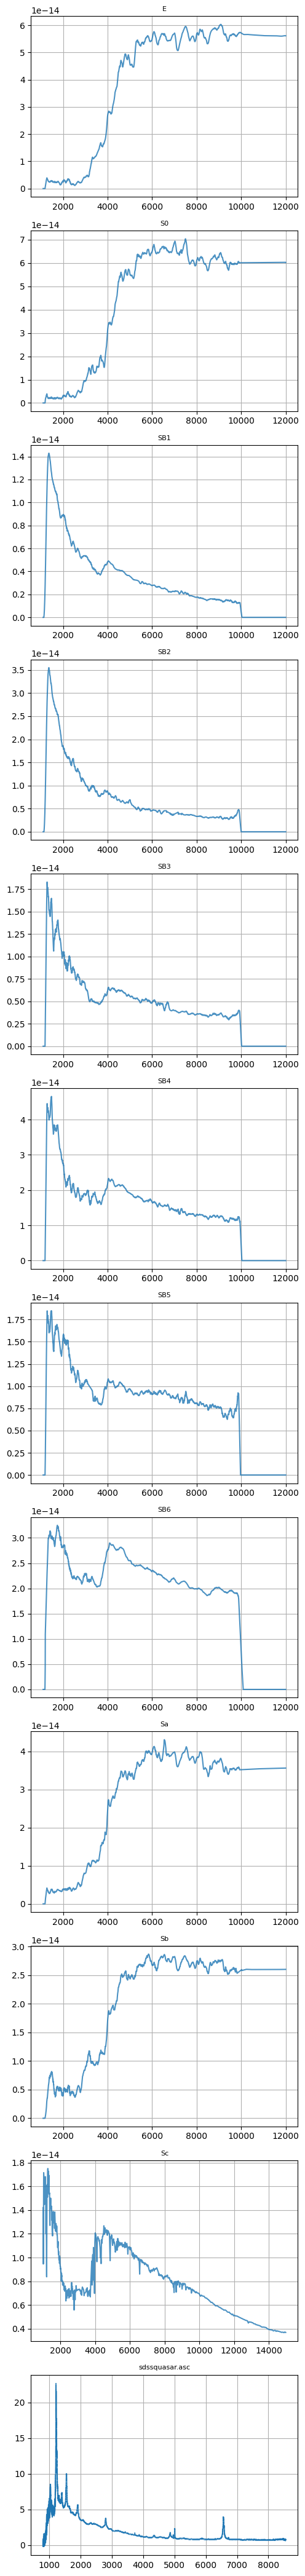

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt

def wavelet_denoise(flux, wavelet='db4', level=2, threshold_scale=1.0):
    
    # Wavelet decomposition
    coeffs = pywt.wavedec(flux, wavelet=wavelet, level=level)
    
    # Estimate noise (using the highest frequency detail coefficients)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = threshold_scale * sigma * np.sqrt(2 * np.log(len(flux)))

    # Soft thresholding (applied only to detail coefficients)
    new_coeffs = [coeffs[0]]  # Keep approximation coefficients (low frequency) unchanged
    for c in coeffs[1:]:
        new_c = pywt.threshold(c, threshold, mode='soft')
        new_coeffs.append(new_c)

    # Reconstruct the signal
    denoised_flux = pywt.waverec(new_coeffs, wavelet)
    
    # Truncate to original length
    return denoised_flux[:len(flux)]

def _read_spectrum_file(filepath, delimiter=None, try_fits=True):
    
    # Try reading as a text file
    try:
        data = np.genfromtxt(filepath, comments='#', delimiter=delimiter, invalid_raise=False, skip_header=1)
        if data is None:
            raise ValueError("genfromtxt returned None")
        data = np.atleast_2d(data)
    except Exception:
        # Try reading as a FITS table
        if try_fits and filepath.lower().endswith(('.fit', '.fits')):
            try:
                from astropy.io import fits
                with fits.open(filepath, memmap=False) as hdul:
                    # Look for the first extension containing data
                    for hdu in hdul:
                        if hasattr(hdu, 'data') and hdu.data is not None:
                            arr = hdu.data
                            # Check if it is a recarray / table-like structure
                            if getattr(arr, 'dtype', None) is not None and arr.dtype.names is not None:
                                # Prioritize 'loglam' and 'flux' columns if present
                                names = arr.dtype.names
                                if 'loglam' in names and 'flux' in names:
                                    wave = 10**arr['loglam'].astype(float)
                                    flux = arr['flux'].astype(float)
                                    err = (arr['ivar'].astype(float)**-0.5) if 'ivar' in names else None
                                    return wave, flux, err
                                else:
                                    # Attempt to extract the first few columns
                                    vals = [arr[name].astype(float) for name in names[:min(3, len(names))]]
                                    data = np.vstack(vals).T
                                    break
                            else:
                                # Data is a standard 1D or 2D array
                                data = np.array(arr)
                                break
                    else:
                        raise IOError("FITS file has no readable data extensions")
            except Exception as ef:
                raise IOError(f"Failed to read FITS via astropy: {ef}")
        else:
            raise IOError(f"Failed to read file as text: {filepath}")

    # Process 2D array data
    if data.ndim == 1:
        # Unexpected: only one column found
        raise IOError(f"Read {filepath} and got 1 column; expected at least 2.")
    
    ncols = data.shape[1]
    if ncols == 2:
        wave = data[:, 0].astype(float)
        flux = data[:, 1].astype(float)
        err = None
    elif ncols == 3:
        wave = data[:, 0].astype(float)
        flux = data[:, 1].astype(float)
        err = data[:, 2].astype(float)
    else:
        # Default to first two columns
        wave = data[:, 0].astype(float)
        flux = data[:, 1].astype(float)
        err = None
    return wave, flux, err


def plot_spectra_from_folder(
    folder_path,
    ncols=1,
    max_files=None,
    overlay=False,
    plot_errbars=True,
    file_exts=None,  
    sub_dir=False,        # Added: Automatically search all subdirectories
    figsize_per_subplot=(5, 3.5),
    delimiter=None,
    try_fits=False,
    verbose=True
):

    # File matching helper
    def _match(fp):
        if file_exts is None:
            return True
        return any(fp.lower().endswith(ext.lower()) for ext in file_exts)

    # ------- Collect Files -------
    files = []

    if sub_dir:   # Recursive search
        for root, _, filenames in os.walk(folder_path):
            for fn in filenames:
                if _match(fn):
                    files.append(os.path.join(root, fn))
    else:
        # Current directory only
        for fn in sorted(os.listdir(folder_path)):
            fp = os.path.join(folder_path, fn)
            if os.path.isfile(fp) and _match(fn):
                files.append(fp)

    if len(files) == 0:
        if verbose:
            print(f"⚠️ No spectrum files found in: {folder_path}")
        return

    if max_files is not None:
        files = files[:max_files]

    # -------- Overlay Mode --------
    if overlay:
        plt.figure(figsize=(10, 6))
        for fp in files:
            try:
                wave, flux, err = _read_spectrum_file(fp, delimiter=delimiter, try_fits=try_fits)
                wave, flux = np.asarray(wave), np.asarray(flux)
                mask = np.isfinite(wave) & np.isfinite(flux)
                wave, flux = wave[mask], flux[mask]
                idx = np.argsort(wave)
                wave, flux = wave[idx], flux[idx]
                label = os.path.basename(fp)

                if plot_errbars and err is not None:
                    err = np.asarray(err)[mask][idx]
                    plt.errorbar(wave, flux, yerr=err, alpha=0.8, label=label)
                else:
                    plt.plot(wave, flux, label=label, alpha=0.8)

            except Exception as e:
                if verbose:
                    print(f"Skipping {fp}: {e}")

        plt.xlabel("Wavelength")
        plt.ylabel("Flux")
        plt.legend(fontsize=8)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        return

    # -------- Grid Subplot Mode --------
    n = len(files)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_subplot[0] * ncols,
                 figsize_per_subplot[1] * nrows),
        squeeze=False
    )

    for idx, fp in enumerate(files):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        try:
            wave, flux, err = _read_spectrum_file(fp, delimiter=delimiter, try_fits=try_fits)
            wave, flux = np.asarray(wave), np.asarray(flux)
            mask = np.isfinite(wave) & np.isfinite(flux)
            wave, flux = wave[mask], flux[mask]
            idx2 = np.argsort(wave)
            wave, flux = wave[idx2], flux[idx2]

            if plot_errbars and err is not None:
                err = np.asarray(err)[mask][idx2]
                ax.errorbar(wave, flux, yerr=err, alpha=0.8)
            else:
                ax.plot(wave, flux, alpha=0.8)

            ax.set_title(os.path.basename(fp), fontsize=8)
            ax.grid(True)

        except Exception as e:
            if verbose:
                print(f"Skipping {fp}: {e}")
            ax.text(0.5, 0.5, "Error", ha='center', va='center')
            ax.axis("off")

    # Hide empty subplots
    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis('off')

    plt.tight_layout()
    plt.show()

# Usage Example
plot_spectra_from_folder("./Spectrum_moudel/bank/original_resolution/gal")

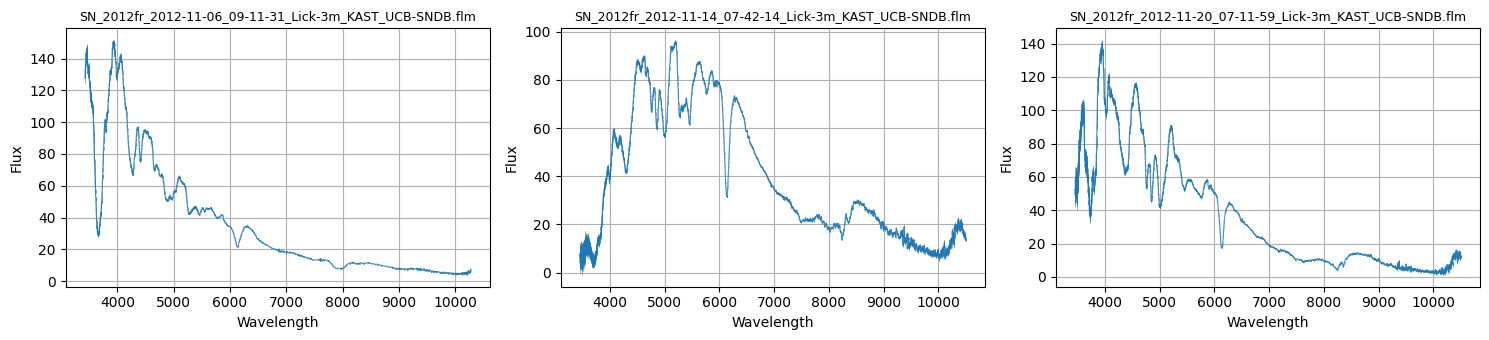

In [28]:
plot_spectra_from_folder("./Spectrum_moudel/bank/original_resolution/sne/Ia-norm/2012fr",file_exts=[".flm"])




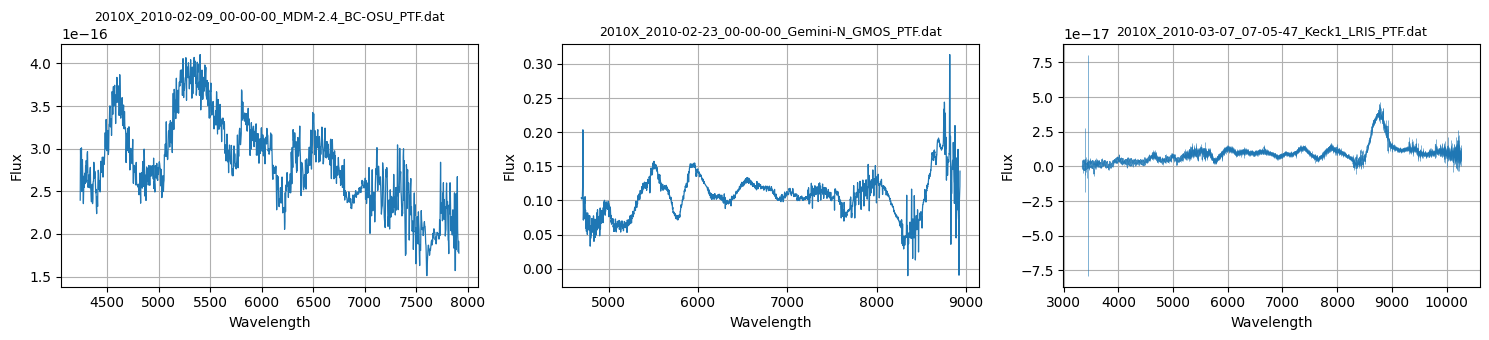

In [34]:
plot_spectra_from_folder("./Spectrum_moudel/bank/original_resolution/sne/Ia-rapid/2010X",file_exts=[".dat"])

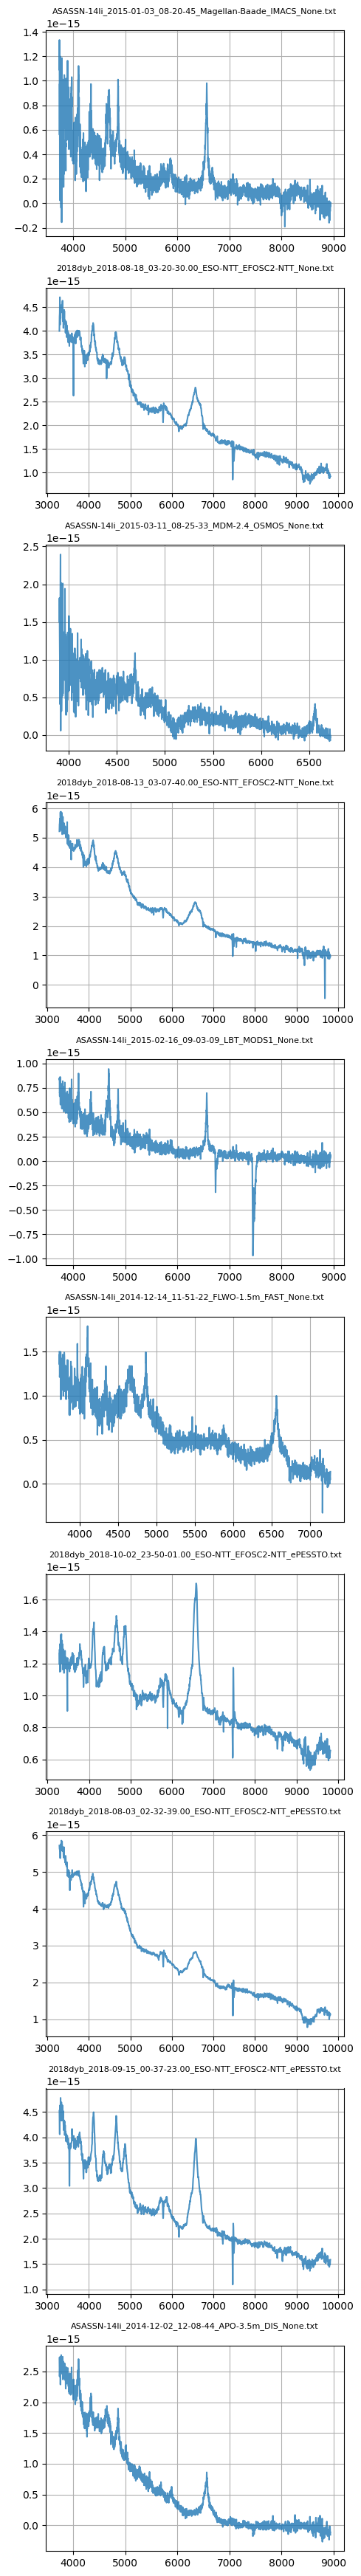

0


In [4]:
plot_spectra_from_folder("./Test set/z_adjust/TDE H+He",
                         file_exts=[".txt", ".dat",".flm",'.ascii','.asci','.','.cal'],
                        sub_dir=True)

print('0')


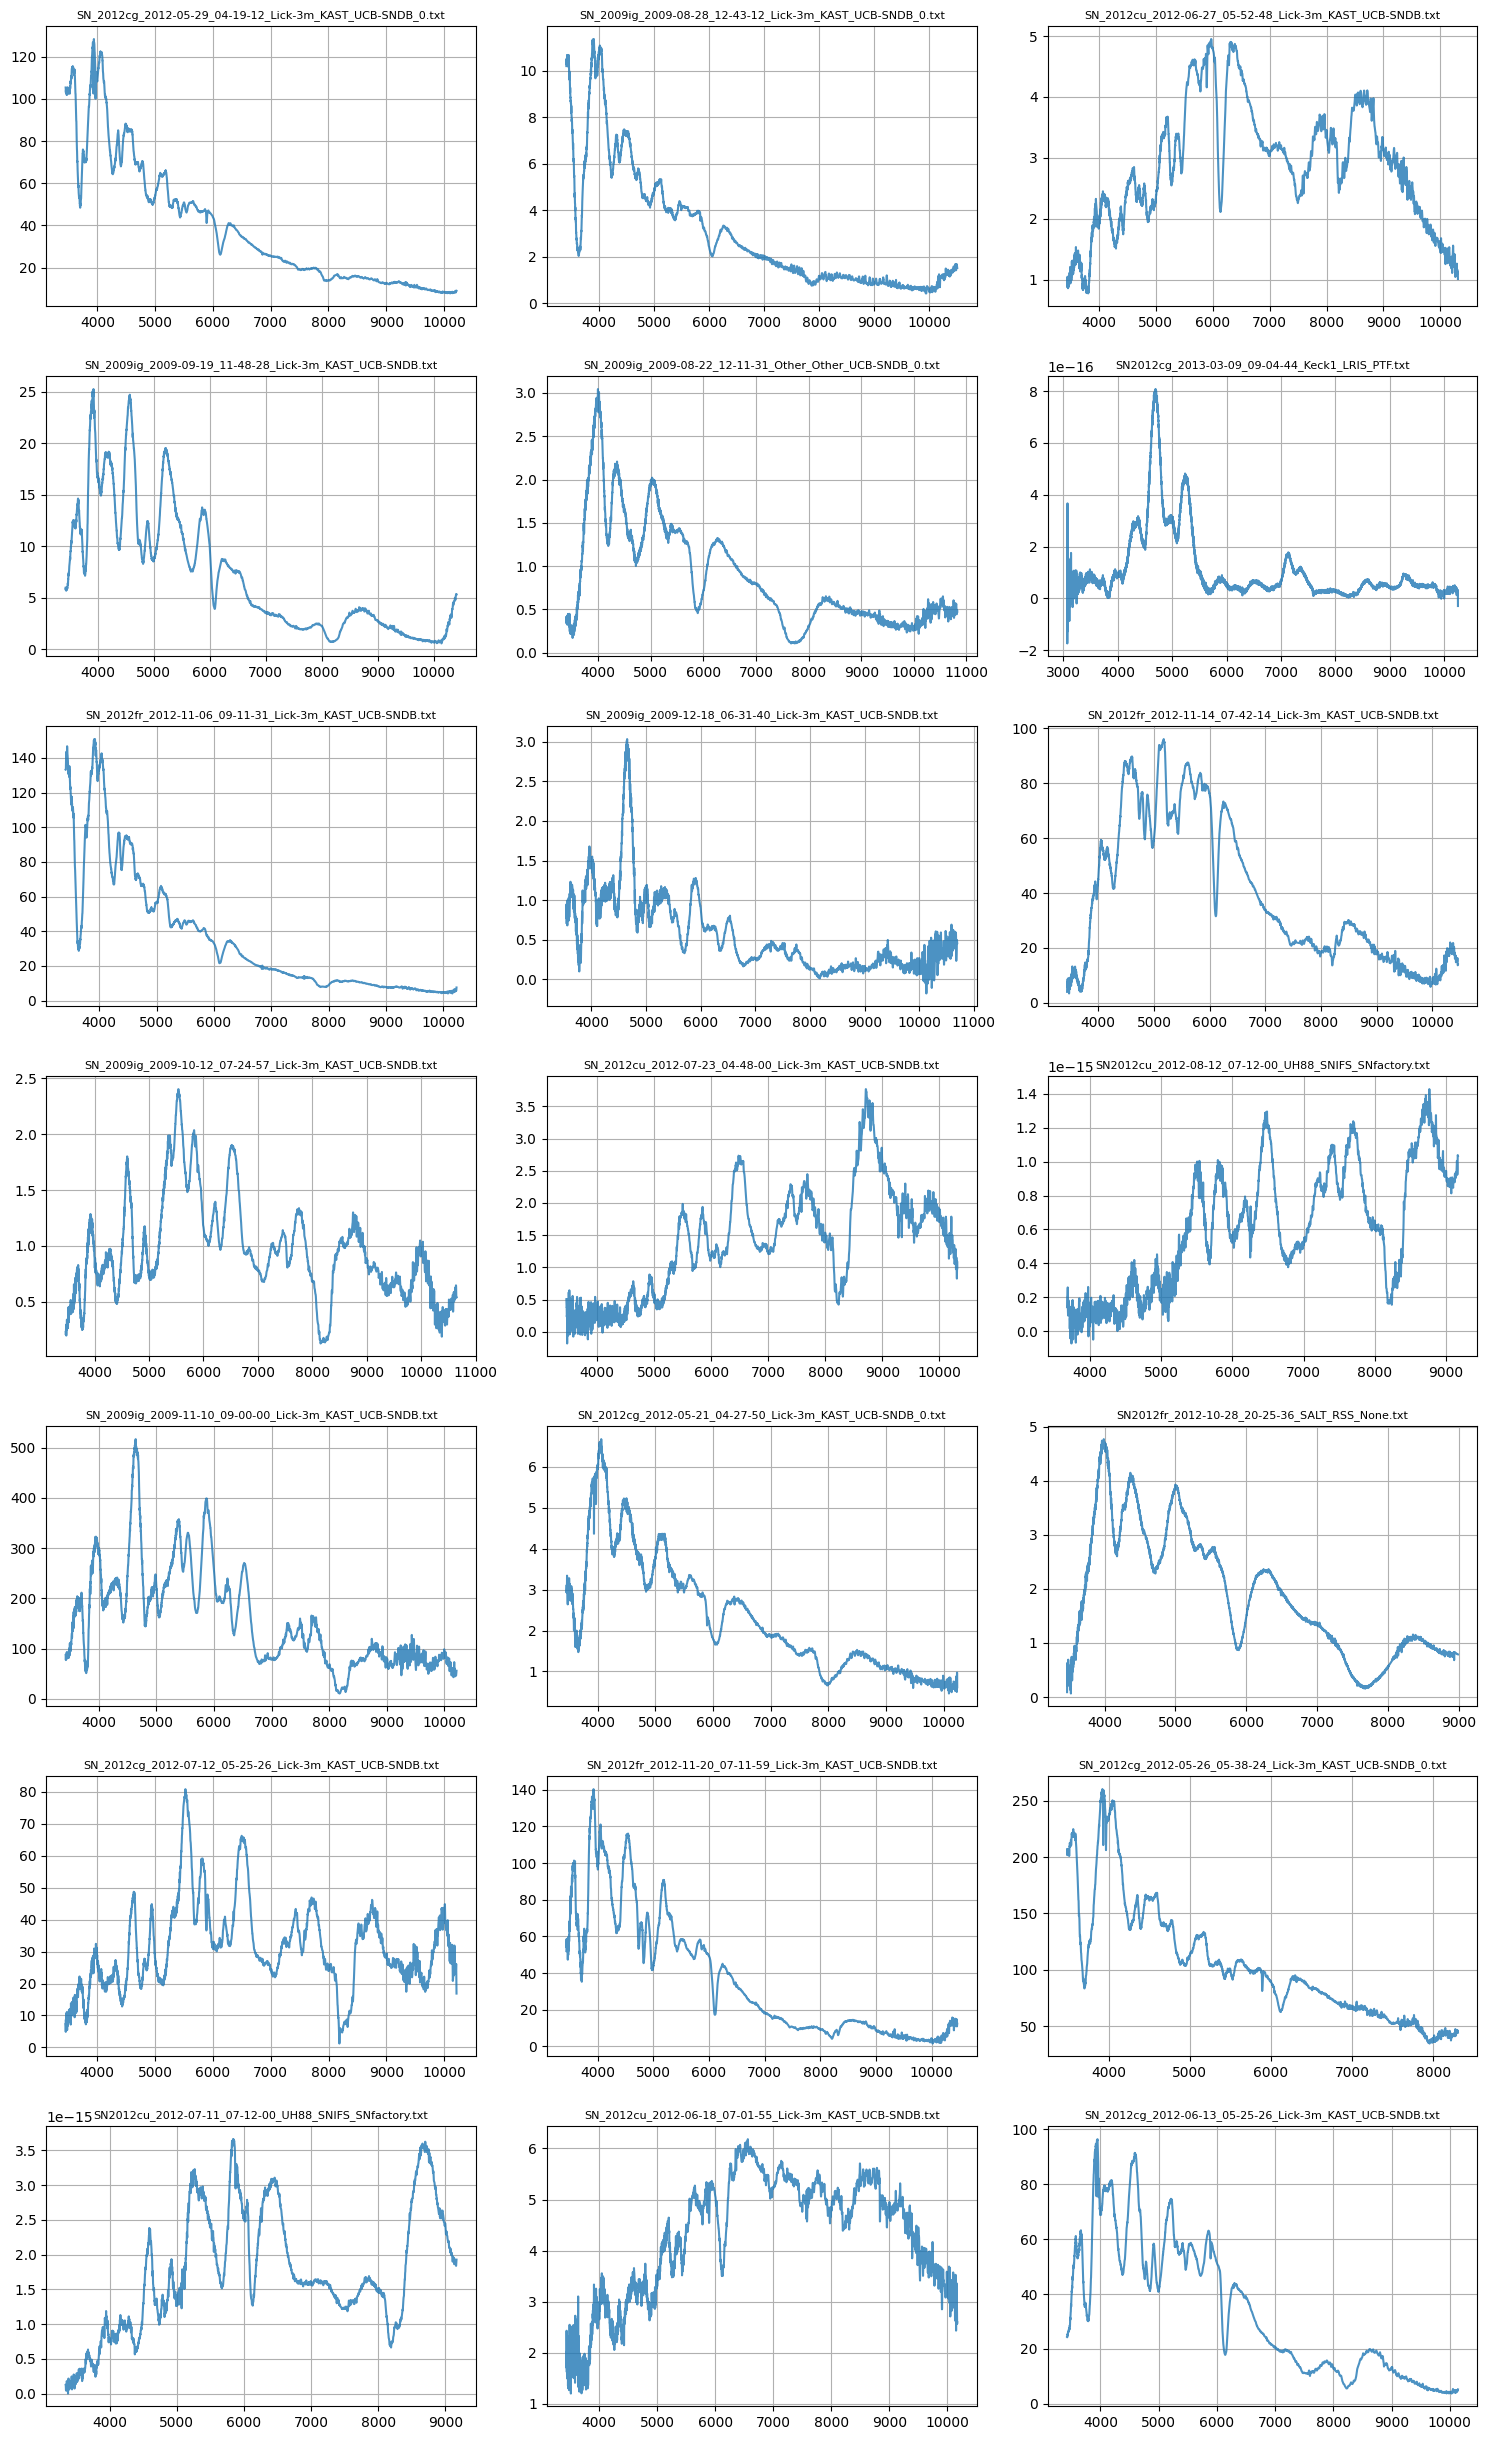

In [7]:
plot_spectra_from_folder("./Test set/z_adjust/Ia-norm",
                         file_exts=[".txt", ".dat",".flm",'.ascii','.asci','.','.cal'],
                        sub_dir=True)

## File Copy and preprocessing

In [50]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

def process_second_level_dirs(
    top_dir,
    target_dir,
    overlay=True,
    max_files=None,
    plot_errbars=True,
    file_exts=None,       
    delimiter=None,
    try_fits=False,
    verbose=True
):
    """
    Iterate through second-level directories under a top-level directory:
    - Plot spectral files from all third-level directories within each second-level directory.
    - Copy all third-level directory files to target_dir/<second_level_dir_name>/.
    - Filter files based on file_exts.
    """
    os.makedirs(target_dir, exist_ok=True)

    # Get all second-level directories
    second_level_dirs = [os.path.join(top_dir, d) for d in os.listdir(top_dir)
                         if os.path.isdir(os.path.join(top_dir, d))]
    
    if len(second_level_dirs) == 0:
        if verbose: print("⚠️ No second-level directories found in the top-level directory")
        return

    # Helper function to match file extensions
    def _match_ext(fp):
        if file_exts is None:
            return True
        return any(fp.lower().endswith(ext.lower()) for ext in file_exts)

    for sec_dir in second_level_dirs:
        sec_name = os.path.basename(sec_dir)
        sec_target_dir = os.path.join(target_dir, sec_name)
        os.makedirs(sec_target_dir, exist_ok=True)

        if verbose: print(f"\n📁 Processing second-level directory: {sec_dir}")

        # Collect files from all third-level directories under the current second-level directory
        files = []
        for third_dir in [os.path.join(sec_dir, d) for d in os.listdir(sec_dir)
                          if os.path.isdir(os.path.join(sec_dir, d))]:
            for fn in os.listdir(third_dir):
                fp = os.path.join(third_dir, fn)
                if os.path.isfile(fp) and _match_ext(fn):
                    files.append(fp)

        if len(files) == 0:
            if verbose: print(f"⚠️ No matching files found in second-level directory: {sec_dir}")
            continue

        if max_files is not None:
            files = files[:max_files]

        # --- Plotting Section ---
        if overlay:
            plt.figure(figsize=(10, 6))
            for fp in files:
                try:
                    # Note: _read_spectrum_file must be defined elsewhere in your script
                    wave, flux, err = _read_spectrum_file(fp, delimiter=delimiter, try_fits=try_fits)
                    wave, flux = np.asarray(wave).ravel(), np.asarray(flux).ravel()
                    mask = np.isfinite(wave) & np.isfinite(flux)
                    
                    if mask.sum() < 2:
                        if verbose: print(f"Skipping (no valid data points): {fp}")
                        continue
                        
                    wave, flux = wave[mask], flux[mask]
                    sort_idx = np.argsort(wave)
                    wave, flux = wave[sort_idx], flux[sort_idx]

                    label = os.path.basename(fp)
                    if plot_errbars and (err is not None):
                        err_arr = np.asarray(err).ravel()[mask][sort_idx]
                        plt.errorbar(wave, flux, yerr=err_arr, label=label,
                                     elinewidth=0.5, linewidth=0.8, alpha=0.8)
                    else:
                        plt.plot(wave, flux, label=label, linewidth=0.8, alpha=0.8)
                except Exception as e:
                    if verbose: print(f"Skipping {fp}: {e}")

            plt.xlabel("Wavelength")
            plt.ylabel("Flux")
            plt.title(f"Spectra: {sec_name}")
            plt.legend(fontsize=8)
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        # --- File Copying Section ---
        for fp in files:
            try:
                shutil.copy(fp, os.path.join(sec_target_dir, os.path.basename(fp)))
            except Exception as e:
                if verbose: print(f"Copy failed for {fp}: {e}")

        if verbose: print(f"✅ Second-level directory {sec_name} processed. Files copied to {sec_target_dir}")

# Example Usage
process_second_level_dirs(
    top_dir="./Spectrum_moudel/bank/original_resolution/sne/",
    target_dir="./Spectrum_moudel/bank/copied_spectra_tes",
    overlay=False,
    max_files=None,
    plot_errbars=False,
    file_exts=[".txt", ".dat", ".flm", ".ascii"]
)


📁 处理二级目录: ./Spectrum_moudel/bank/original_resolution/sne/ILRT
✅ 二级目录 ILRT 处理完成，文件已复制到 ./Spectrum_moudel/bank/copied_spectra_tes/ILRT

📁 处理二级目录: ./Spectrum_moudel/bank/original_resolution/sne/Ia 02es-like
✅ 二级目录 Ia 02es-like 处理完成，文件已复制到 ./Spectrum_moudel/bank/copied_spectra_tes/Ia 02es-like

📁 处理二级目录: ./Spectrum_moudel/bank/original_resolution/sne/super_chandra
✅ 二级目录 super_chandra 处理完成，文件已复制到 ./Spectrum_moudel/bank/copied_spectra_tes/super_chandra

📁 处理二级目录: ./Spectrum_moudel/bank/original_resolution/sne/Ic-pec
✅ 二级目录 Ic-pec 处理完成，文件已复制到 ./Spectrum_moudel/bank/copied_spectra_tes/Ic-pec

📁 处理二级目录: ./Spectrum_moudel/bank/original_resolution/sne/Ia 99aa-like
✅ 二级目录 Ia 99aa-like 处理完成，文件已复制到 ./Spectrum_moudel/bank/copied_spectra_tes/Ia 99aa-like

📁 处理二级目录: ./Spectrum_moudel/bank/original_resolution/sne/Ca-Ia
✅ 二级目录 Ca-Ia 处理完成，文件已复制到 ./Spectrum_moudel/bank/copied_spectra_tes/Ca-Ia

📁 处理二级目录: ./Spectrum_moudel/bank/original_resolution/sne/Ib
✅ 二级目录 Ib 处理完成，文件已复制到 ./Spectrum_moudel/bank/copied

## New-Samples: Spectra Mixing

In [64]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
import random

def read_spectrum(file_path):
    data = np.loadtxt(file_path)
    wavelength, flux = data[:, 0], data[:, 1]
    return wavelength, flux

def normalize_flux(flux):
    return flux / np.nanmax(np.abs(flux))

def interpolate_flux(wave_src, flux_src, wave_target):
    interp_func = interp1d(wave_src, flux_src, bounds_error=False,
                           fill_value=(flux_src[0], flux_src[-1]))
    return interp_func(wave_target)

def generate_mixed_spectrum(trans_wave, trans_flux, host_wave, host_flux, scale_factor, base_noise=0.3):
    """
    Generates a superimposed spectrum and adds noise. 
    Noise intensity varies with scale_factor such that noise_level * scale = base_noise.
    """

    # Ensure the common band covers 4000–7000Å
    wave_min = max(trans_wave.min(), host_wave.min())
    wave_max = min(trans_wave.max(), host_wave.max())
    if wave_min > 4100 or wave_max < 6980:
        return None, None  # Insufficient coverage, skip

    common_wave = np.linspace(4000, 7000, 2000)  # Specified band range

    # Interpolate to common wavelengths
    trans_flux_interp = interpolate_flux(trans_wave, trans_flux, common_wave)
    host_flux_interp = interpolate_flux(host_wave, host_flux, common_wave)

    # Scaling + Superposition
    mixed_flux = trans_flux_interp + scale_factor * host_flux_interp
    mixed_flux = normalize_flux(mixed_flux)

    # ---- Dynamic Noise Level ----
    # Goal: noise_level * scale_factor = base_noise
    # ==> noise_level = base_noise / scale_factor
    noise_level = 0.2 / (scale_factor + 1)
    noise_sigma = noise_level * np.std(mixed_flux)

    # Add Gaussian noise
    noise = np.random.normal(0, noise_sigma, size=mixed_flux.shape)
    mixed_flux_noisy = mixed_flux + noise

    return common_wave, mixed_flux_noisy

def process_all(
    trans_folder,
    host_folder,
    output_folder,
    scale_range=(0.1, 1.0),
    max_pairs_per_transient=3,
    visualize_n=5
):
    os.makedirs(output_folder, exist_ok=True)

    # Transient sources: supported extensions
    trans_exts = ('.txt', '.dat', '.ascii', '.flm')
    trans_files = sorted([
        os.path.join(trans_folder, f)
        for f in os.listdir(trans_folder)
        if f.lower().endswith(trans_exts)
    ])

    # Host galaxies: read only .txt and .dat
    host_exts = ('.txt', '.dat')
    host_files = sorted([
        os.path.join(host_folder, f)
        for f in os.listdir(host_folder)
        if f.lower().endswith(host_exts)
    ])

    fig_id = 0
    n_hosts = len(host_files)
    total_saved = 0

    # scale_values depends on scale_range
    step = (scale_range[1] - scale_range[0]) / (max_pairs_per_transient - 1)
    scale_values = np.arange(scale_range[0], scale_range[1] + step, step).round(2)

    for i, trans_file in enumerate(tqdm(trans_files, desc="Processing spectra")):
        # Note: _read_spectrum_file should be defined elsewhere (as in your previous scripts)
        trans_wave, trans_flux, flux_err = _read_spectrum_file(trans_file)
        trans_flux = normalize_flux(trans_flux)

        n_pairs = min(len(scale_values), n_hosts)
        indices = np.linspace(0, n_hosts - 1, n_pairs, dtype=int)
        chosen_hosts = [host_files[idx] for idx in indices]

        for j, (host_file, scale) in enumerate(zip(chosen_hosts, scale_values)):
            host_wave, host_flux = read_spectrum(host_file)
            host_flux = normalize_flux(host_flux)

            mixed_wave, mixed_flux = generate_mixed_spectrum(
                trans_wave, trans_flux, host_wave, host_flux, scale
            )

            if mixed_wave is None:
                continue

            output_name = f"mixed_{i:04d}_{j:02d}_scale{scale:.2f}.txt"
            np.savetxt(os.path.join(output_folder, output_name),
                       np.column_stack([mixed_wave, mixed_flux]))
            total_saved += 1

            # Visualization
            if fig_id < visualize_n:
                plt.figure(figsize=(8, 5))
                plt.plot(mixed_wave, mixed_flux, label=f'Mixed (scale={scale:.2f})', color='black')
                plt.plot(mixed_wave, interpolate_flux(trans_wave, trans_flux, mixed_wave),
                         label='Transient', alpha=0.3)
                plt.plot(mixed_wave, interpolate_flux(host_wave, host_flux, mixed_wave),
                         label='Scaled Host', alpha=0.3)
                plt.legend()
                plt.title(f'Mixed Spectrum {fig_id}')
                plt.xlabel('Wavelength')
                plt.ylabel('Normalized Flux')
                plt.tight_layout()
                plt.show()
                fig_id += 1

    print(f"\n✅ Synthesis complete. Total files generated: {total_saved}")


def batch_process_all(
    process_all_func,
    transient_folders,
    host_folders,
    base_output_folder,
    name_map=None,
    scale_dict=None,
    **kwargs
):
    """
    Iterates through combinations of transient_folders and host_folders,
    calls process_all_func, and outputs the corresponding scale_range for verification.
    """
    name_map = name_map or {}
    scale_dict = scale_dict or {}

    for trans_name, trans_path in transient_folders.items():
        for host_name, host_path in host_folders.items():
            short_host_name = name_map.get(host_name, host_name)
            combo_key = f"{trans_name.replace(' ', '_')}+{short_host_name.replace(' ', '_')}"
            output_path = os.path.join(base_output_folder, combo_key)
            
            # Get the specific scale_range for this combination
            combo_scale_range = scale_dict.get(combo_key, kwargs.get("scale_range", (0.1, 1.0)))

            # ✅ Print processing info including scale_range
            print(f"\n🔧 Processing: {trans_name} + {host_name} -> {output_path}")
            print(f"   📏 scale_range = {combo_scale_range}")

            os.makedirs(output_path, exist_ok=True)

            # Create new kwargs to avoid double-passing scale_range
            process_kwargs = dict(kwargs)
            process_kwargs.pop("scale_range", None)

            # ✅ Call sub-routine
            process_all_func(
                trans_folder=trans_path,
                host_folder=host_path,
                output_folder=output_path,
                scale_range=combo_scale_range,
                **process_kwargs
            )

## For Running on Real Data:




transient_classes = {

     "TDE H":"./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/TDE H",
     "TDE He":"./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/TDE He",
     "TDE H+He":"./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/TDE H+He",
     "SN Ia": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ia-norm",
     "SN Ia 91bg": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ia 91bg-like",
     "SN Ia 91T": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ia 91T-like",
     "SN Ia 02es": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ia 02es-like",
     "SN Ia 02cx": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ia-02cx like",
     "SN Ia 99aa": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ia 99aa-like",
     "SN Ibn": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ibn",
     "SN Ib": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ib",
     "SN Ic": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/Ic",
     "SN II": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/II",
     "SN IIb": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/IIb",
     "SN IIn": "./Spectrum_moudel/bank/copied_spectra_tes_z_justed_1/IIn",
}




#"AGN": "./New_Class_1/Galaxy/AGN",
#"AGN BROADLINE": "./New_Class_1/Galaxy/AGN BROADLINE",

host_classes = {
    
    "Featureless": "./New_Class_1/Galaxy/Featureless",
    "STARFORMING": "./New_Class_1/Galaxy/STARFORMING",
    "STARBURST": "./New_Class_1/Galaxy/STARBURST",
    "AGN": "./New_Class_1/Galaxy/AGN",
    "AGN BROADLINE": "./New_Class_1/Galaxy/AGN BROADLINE",
}

name_map = {

    "STARFORMING": "SF",
    "AGN BROADLINE": "AGN_BDL",
    "AGN": "AGN",
    "STARBURST":"SB",
    "Featureless":"FL"
    
}

## For Training:


transient_classes = {

     "TDE H":"./Train set/z_adjust/TDE H",
     "TDE He":"./Train set/z_adjust/TDE He",
     "TDE H+He":"./Train set/z_adjust/TDE H+He",
     "SN Ia": "./Train set/z_adjust/Ia-norm",
     "SN Ia 91bg": "./Train set/z_adjust/Ia 91bg-like",
     "SN Ia 91T": "./Train set/z_adjust/Ia 91T-like",
     "SN Ia 02es": "./Train set/z_adjust/Ia 02es-like",
     "SN Ia 02cx": "./Train set/z_adjust/Ia-02cx like",
     "SN Ia 99aa": "./Train set/z_adjust/Ia 99aa-like",
     "SN Ibn": "./Train set/z_adjust/Ibn",
     "SN Ib": "./Train set/z_adjust/Ib",
     "SN Ic": "./Train set/z_adjust/Ic",
     "SN II": "./Train set/z_adjust/II",
     "SN IIb": "./Train set/z_adjust/IIb",
     "SN IIn": "./Train set/z_adjust/IIn",
}




#"AGN": "./New_Class_1/Galaxy/AGN",
#"AGN BROADLINE": "./New_Class_1/Galaxy/AGN BROADLINE",

host_classes = {
    
    "Featureless": "./Train set/Galaxy/Featureless",
    "STARFORMING": "./Train set/Galaxy/STARFORMING",
    "STARBURST": "./Train set/Galaxy/STARBURST",
    "AGN": "./Train set/Galaxy/AGN",
    "AGN BROADLINE": "./Train set/Galaxy/AGN BROADLINE",
}

name_map = {

    "STARFORMING": "SF",
    "AGN BROADLINE": "AGN_BDL",
    "AGN": "AGN",
    "STARBURST":"SB",
    "Featureless":"FL"
    
}


## For Testing:

transient_classes = {

     "TDE H":"./Test set/z_adjust/TDE H",
     "TDE He":"./Test set/z_adjust/TDE He",
     "TDE H+He":"./Test set/z_adjust/TDE H+He",
     "SN Ia": "./Test set/z_adjust/Ia-norm",
     "SN Ia 91bg": "./Test set/z_adjust/Ia 91bg-like",
     "SN Ia 91T": "./Test set/z_adjust/Ia 91T-like",
     "SN Ia 02es": "./Test set/z_adjust/Ia 02es-like",
     "SN Ia 02cx": "./Test set/z_adjust/Ia-02cx like",
     "SN Ia 99aa": "./Test set/z_adjust/Ia 99aa-like",
     "SN Ibn": "./Test set/z_adjust/Ibn",
     "SN Ib": "./Test set/z_adjust/Ib",
     "SN Ic": "./Test set/z_adjust/Ic",
     "SN II": "./Test set/z_adjust/II",
     "SN IIb": "./Test set/z_adjust/IIb",
     "SN IIn": "./Test set/z_adjust/IIn",
}




#"AGN": "./New_Class_1/Galaxy/AGN",
#"AGN BROADLINE": "./New_Class_1/Galaxy/AGN BROADLINE",

host_classes = {
    
    "Featureless": "./Test set/Galaxy/Featureless",
    "STARFORMING": "./Test set/Galaxy/STARFORMING",
    "STARBURST": "./Test set/Galaxy/STARBURST"
    "AGN": "./Test set/Galaxy/AGN",
    "AGN BROADLINE": "./Test set/Galaxy/AGN BROADLINE",
}

name_map = {

    "STARFORMING": "SF",
    "AGN BROADLINE": "AGN_BDL",
    "AGN": "AGN",
    "STARBURST":"SB",
    "Featureless":"FL"
    
}


In [66]:

transient_classes = {

     "TDE H":"./Train set/z_adjust/TDE H",
     "TDE He":"./Train set/z_adjust/TDE He",
     "TDE H+He":"./Train set/z_adjust/TDE H+He",
     "SN Ia": "./Train set/z_adjust/Ia-norm",
     "SN Ia 91bg": "./Train set/z_adjust/Ia 91bg-like",
     "SN Ia 91T": "./Train set/z_adjust/Ia 91T-like",
     "SN Ia 02es": "./Train set/z_adjust/Ia 02es-like",
     "SN Ia 02cx": "./Train set/z_adjust/Ia-02cx like",
     "SN Ia 99aa": "./Train set/z_adjust/Ia 99aa-like",
     "SN Ibn": "./Train set/z_adjust/Ibn",
     "SN Ib": "./Train set/z_adjust/Ib",
     "SN Ic": "./Train set/z_adjust/Ic",
     "SN II": "./Train set/z_adjust/II",
     "SN IIb": "./Train set/z_adjust/IIb",
     "SN IIn": "./Train set/z_adjust/IIn",
}




#"AGN": "./New_Class_1/Galaxy/AGN",
#"AGN BROADLINE": "./New_Class_1/Galaxy/AGN BROADLINE",

host_classes = {
    
    "Featureless": "./Train set/Galaxy/Featureless",
    "STARFORMING": "./Train set/Galaxy/STARFORMING",
    "STARBURST": "./Train set/Galaxy/STARBURST",
    "AGN": "./Train set/Galaxy/AGN",
    "AGN BROADLINE": "./Train set/Galaxy/AGN BROADLINE",
}

name_map = {

    "STARFORMING": "SF",
    "AGN BROADLINE": "AGN_BDL",
    "AGN": "AGN",
    "STARBURST":"SB",
    "Featureless":"FL"
    
}

scale_dict = {
    
    "TDE_H+FL":(0.0, 5.0),
    "TDE_H+SB":(0.0, 5.0),
    "TDE_H+SF":(0.0, 5.0),
    "TDE_He+FL":(0.0, 5.0),
    "TDE_He+SB":(0.0, 5.0),
    "TDE_He+SF":(0.0, 5.0),
    "TDE_H+He+FL":(0.0, 5.0),
    "TDE_H+He+SB":(0.0, 5.0),
    "TDE_H+He+SF":(0.0, 5.0),
    
    
    "SN_Ia+FL": (0.0, 50.0),
    "SN_Ia+SB": (0.0, 50.0),
    "SN_Ia+SF": (0.0, 50.0),
    
    "SN_Ia_91bg+FL": (0.0, 50.0),
    "SN_Ia_91T+FL": (0.0, 50.0),
    "SN_Ia_02es+FL": (0.0, 50.0),
    "SN_Ia_02cx+FL": (0.0, 50.0),
    "SN_Ia_99aa+FL": (0.0, 50.0),
    
    "SN_Ia_91bg+SB": (0.0, 50.0),
    "SN_Ia_91T+SB": (0.0, 50.0),
    "SN_Ia_02es+SB": (0.0, 50.0),
    "SN_Ia_02cx+SB": (0.0, 50.0),
    "SN_Ia_99aa+SB": (0.0, 50.0),
    
    "SN_Ia_91bg+SF": (0.0, 50.0),
    "SN_Ia_91T+SF": (0.0, 50.0),
    "SN_Ia_02es+SF": (0.0, 50.0),
    "SN_Ia_02cx+SF": (0.0, 50.0),
    "SN_Ia_99aa+SF": (0.0, 50.0),
    
    
    
    
    
    "SN_Ib+FL": (0.0, 50.0),
    "SN_Ib+SB": (0.0, 50.0),
    "SN_Ib+SF": (0.0, 50.0),
    
    "SN_Ibn+FL": (0.0, 50.0),     
    "SN_Ibn+SB": (0.0, 50.0),     
    "SN_Ibn+SF": (0.0, 50.0),
    
    
    
    "SN_Ic+FL": (0.0, 50.0),
    "SN_Ic+SB": (0.0, 50.0),
    "SN_Ic+SF": (0.0, 50.0),
    
    
    
    "SN_II+FL": (0.0, 50.0),
    "SN_II+SB": (0.0, 50.0),
    "SN_II+SF": (0.0, 50.0),
    
    "SN_IIn+FL": (0.0, 50.0),
    "SN_IIn+SB": (0.0, 50.0),
    "SN_IIn+SF": (0.0, 50.0),
    
    "SN_IIb+FL": (0.0, 50),
    "SN_IIb+SB": (0.0, 50),
    "SN_IIb+SF": (0.0, 50.0),
    
    
    
    
    # 其他组合可继续添加...
}



#调用批处理函数
batch_process_all(
    process_all_func=process_all,
    transient_folders=transient_classes,
    host_folders=host_classes,
    name_map=name_map,
    base_output_folder="/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_train",
    scale_dict=scale_dict,
    scale_range=(0.0, 50),  # default fallback
    max_pairs_per_transient=101,
    visualize_n=0
)

#Mixed_Spectrum_test_11 之前数据的暂现源全部没有经过正确的红移校正


🔧 正在处理: TDE H + Featureless -> /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_train/TDE_H+FL
   📏 scale_range = (0.0, 5.0)


Processing spectra: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:10<00:00,  1.73s/it]



✅ 合成完成，总生成文件数: 594

🔧 正在处理: TDE H + STARFORMING -> /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_train/TDE_H+SF
   📏 scale_range = (0.0, 5.0)


Processing spectra: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:10<00:00,  1.75s/it]



✅ 合成完成，总生成文件数: 582

🔧 正在处理: TDE H + STARBURST -> /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_train/TDE_H+SB
   📏 scale_range = (0.0, 5.0)


...


✅ 合成完成，总生成文件数: 2800

🔧 正在处理: SN IIn + AGN -> /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_train/SN_IIn+AGN
   📏 scale_range = (0.0, 50)


Processing spectra: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:46<00:00,  1.61s/it]



✅ 合成完成，总生成文件数: 2800

🔧 正在处理: SN IIn + AGN BROADLINE -> /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_train/SN_IIn+AGN_BDL
   📏 scale_range = (0.0, 50)


Processing spectra: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:46<00:00,  1.61s/it]


✅ 合成完成，总生成文件数: 2744


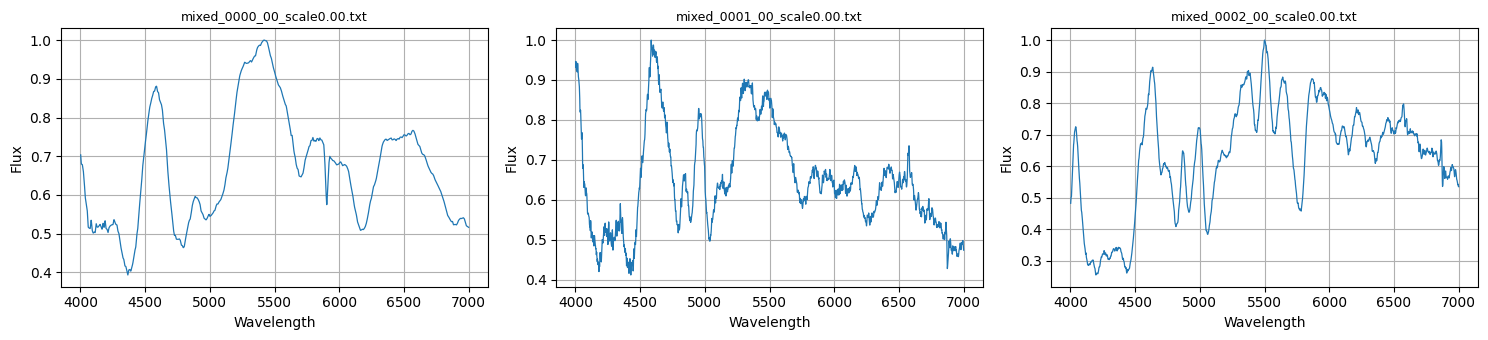

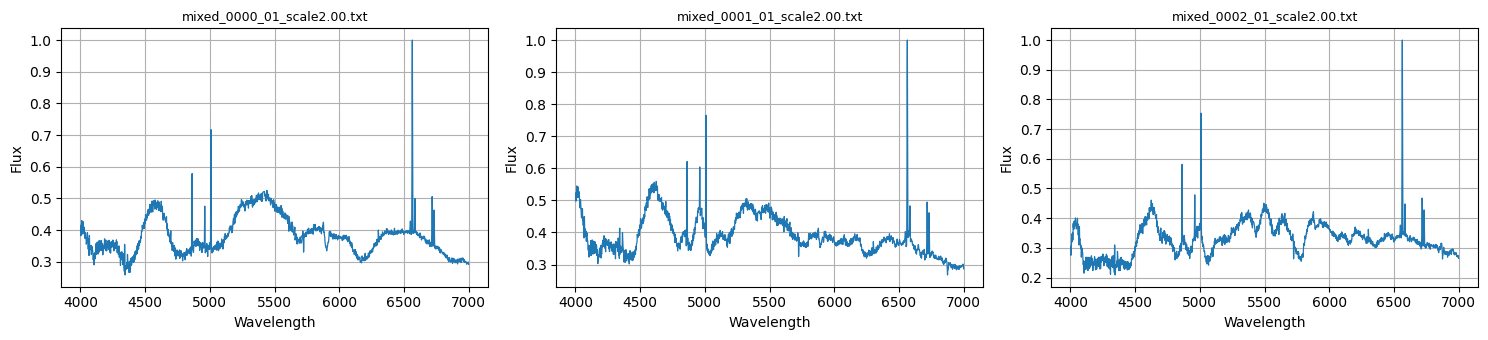

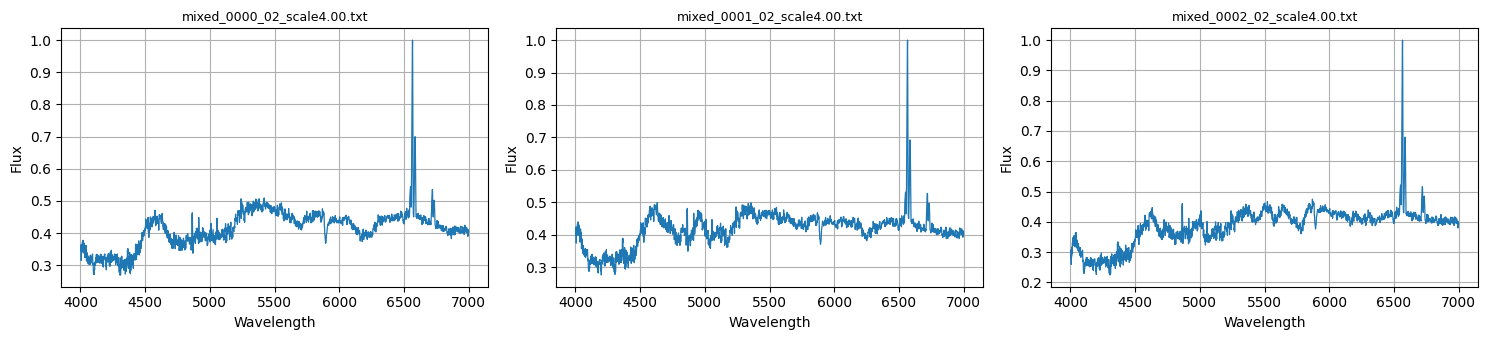

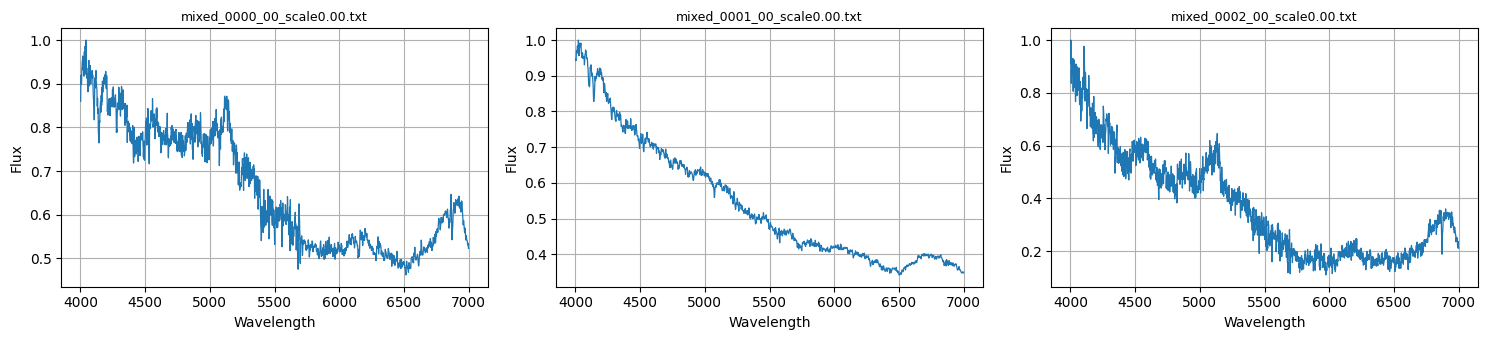

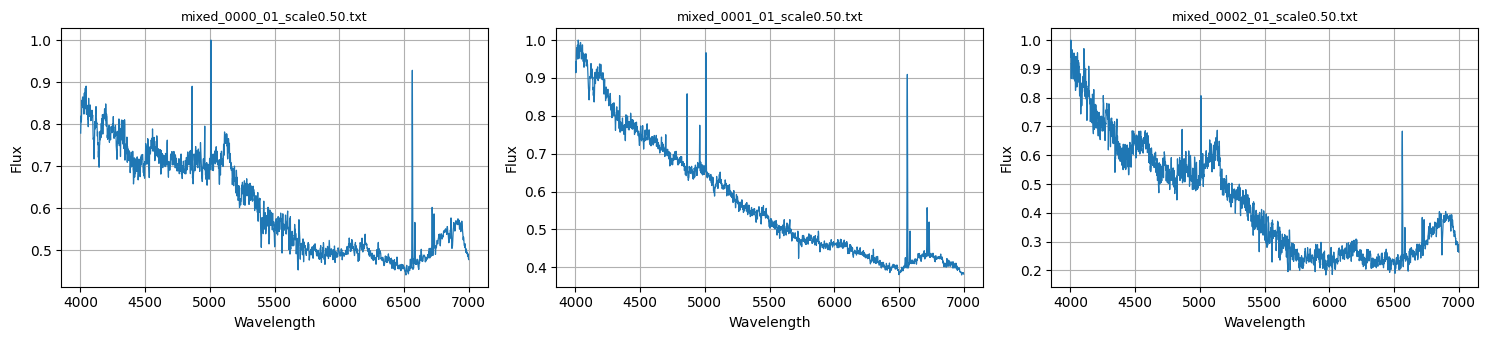

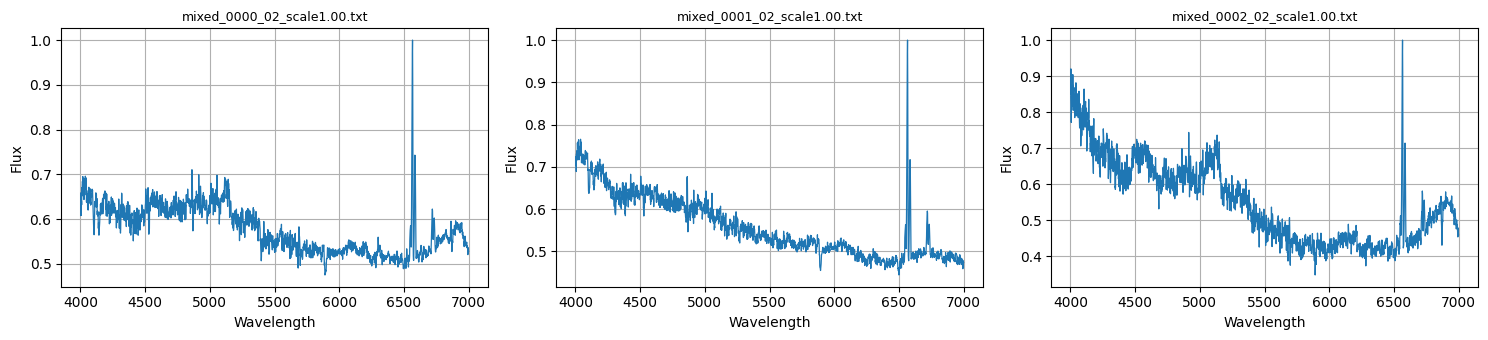

In [131]:
plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_1/TDE+SF",
                         file_exts=[".ascii",".flm",'.dat','e0.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_1/SN_Ic+SF",
                         file_exts=[".ascii",".flm",'.dat','e2.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_1/SN_Ic+SF",
                         file_exts=[".ascii",".flm",'.dat','e4.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_1/TDE_H+SF",
                         file_exts=[".ascii",".flm",'.dat','e0.00.txt'],
                         max_files=3,)


plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_1/TDE_H+SF",
                         file_exts=[".ascii",".flm",'.dat','e0.50.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_1/TDE_H+SF",
                         file_exts=[".ascii",".flm",'.dat','e1.00.txt'],
                         max_files=3,)




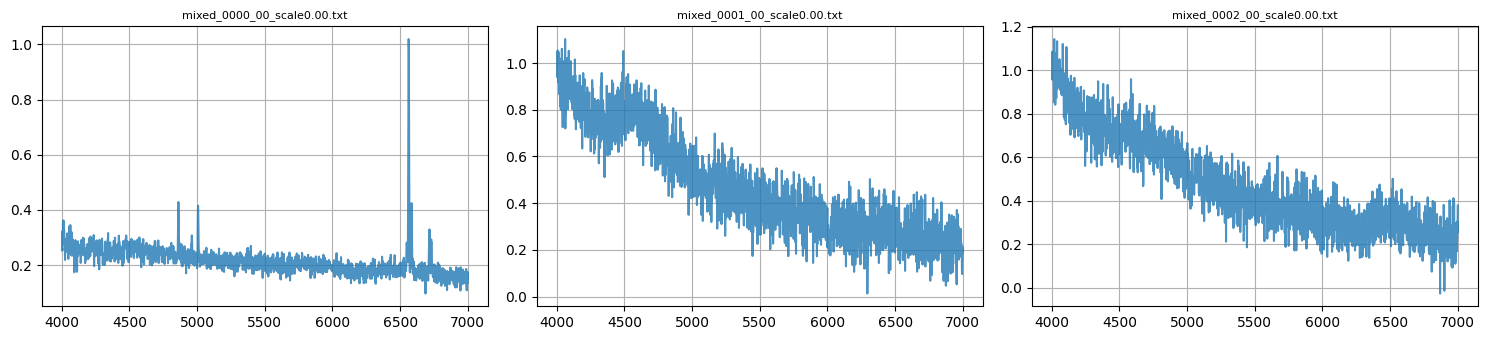

In [55]:
plot_spectra_from_folder("/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_test_27_test_noise/SN_II+FL",
                         file_exts=[".ascii",".flm",'.dat','e0.00.txt'],
                         max_files=3,)




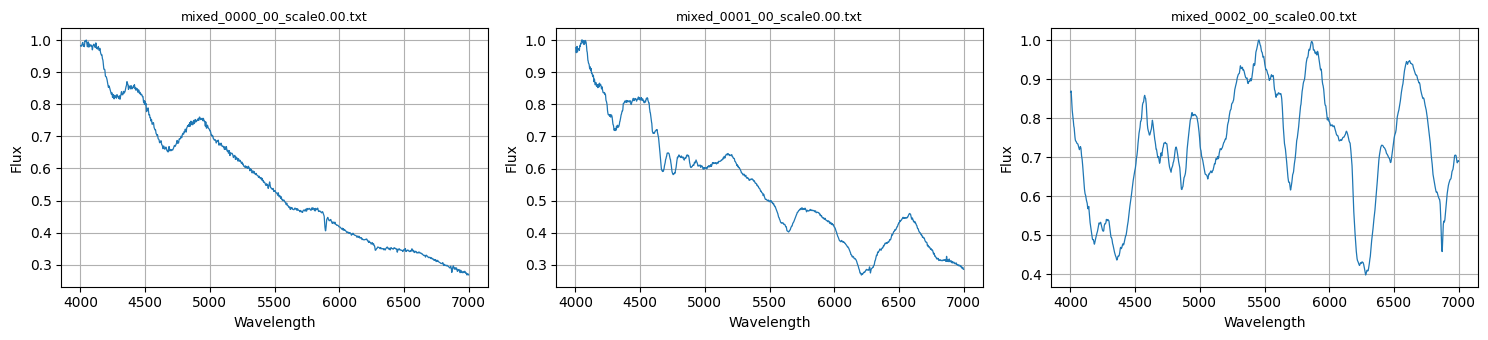

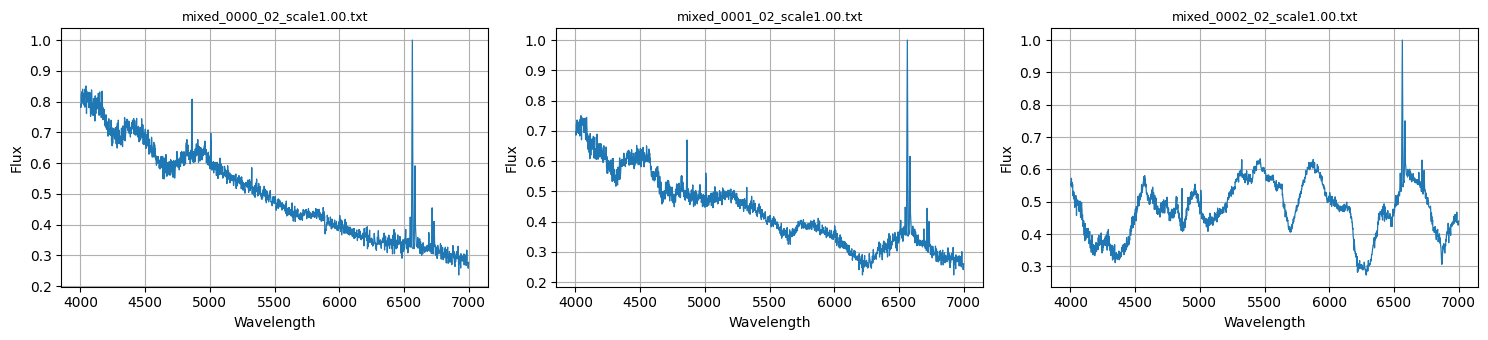

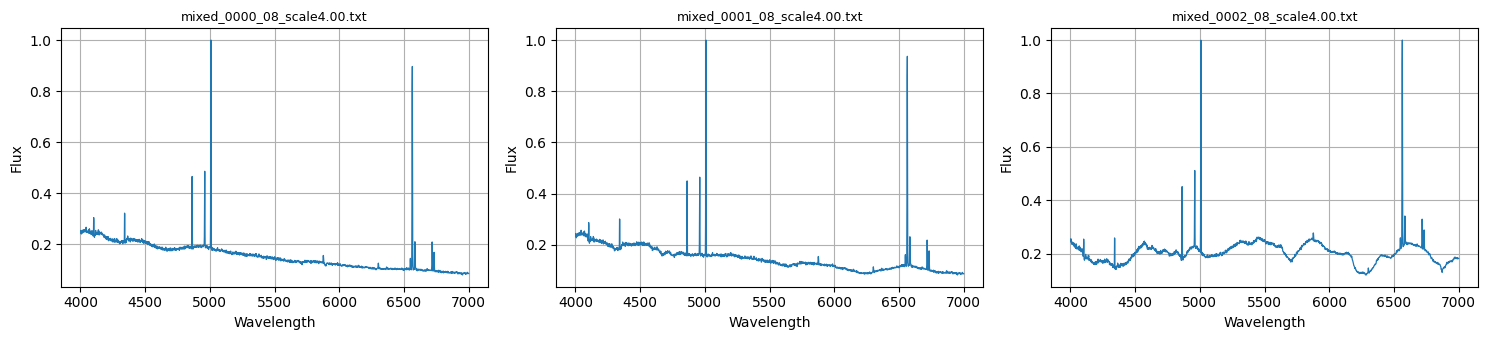

⚠️ 未找到可处理的文件。
⚠️ 未找到可处理的文件。
⚠️ 未找到可处理的文件。


In [103]:
plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_3/SN_IIb+SB",
                         file_exts=[".ascii",".flm",'.dat','e0.00.txt'],
                         max_files=3,)


plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_3/SN_IIb+SB",
                         file_exts=[".ascii",".flm",'.dat','e1.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_3/SN_IIb+SB",
                         file_exts=[".ascii",".flm",'.dat','e4.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_3/SN_IIb+SB",
                         file_exts=[".ascii",".flm",'.dat','e6.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_3/SN_IIb+SB",
                         file_exts=[".ascii",".flm",'.dat','e8.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_3/SN_IIb+SB",
                         file_exts=[".ascii",".flm",'.dat','e10.00.txt'],
                         max_files=3,)

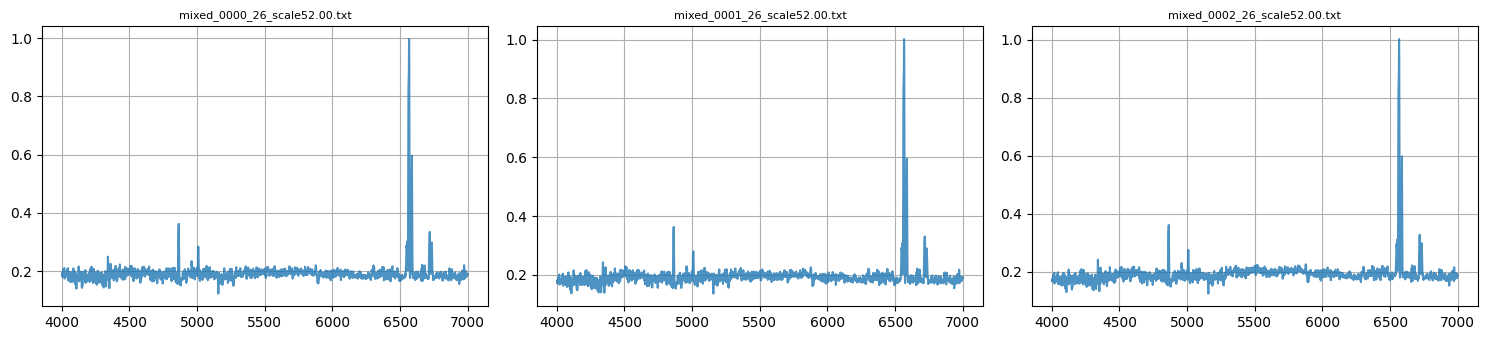

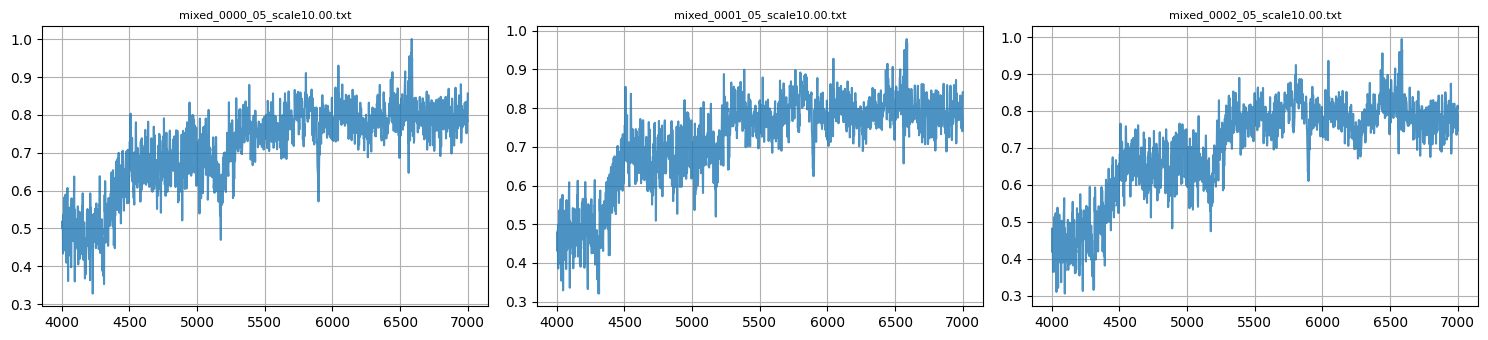

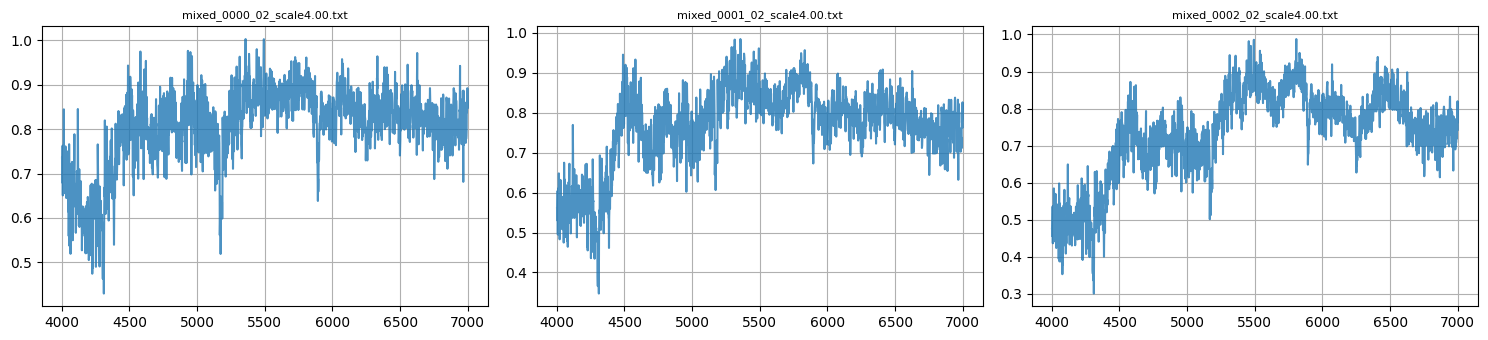

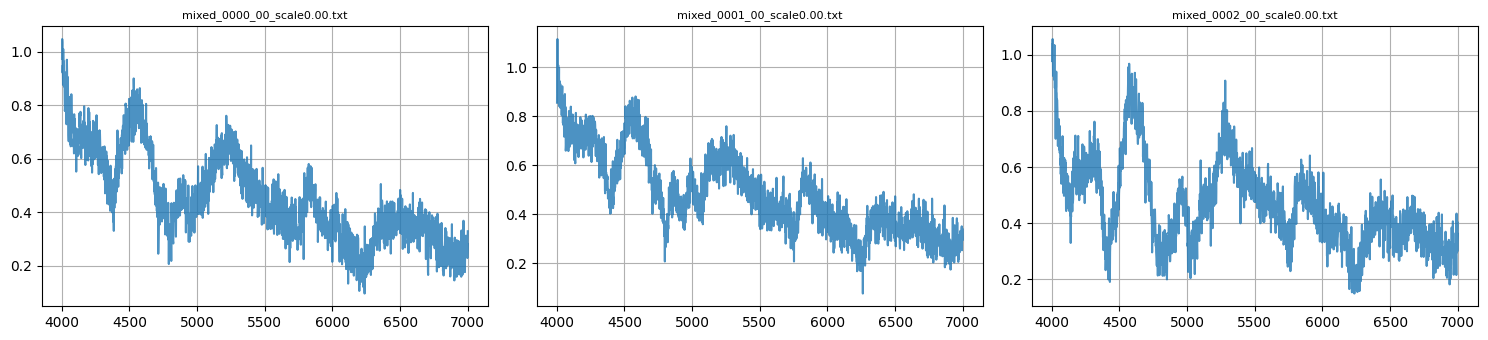

In [29]:
plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_21_noise/SN_Ia+SB",
                         file_exts=[".ascii",".flm",'.dat','e52.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_21_noise/SN_Ia+FL",
                         file_exts=[".ascii",".flm",'.dat','e10.00.txt'],
                         max_files=3,)


plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_21_noise/SN_Ia+FL",
                         file_exts=[".ascii",".flm",'.dat','e4.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_21_noise/SN_Ib+FL",
                         file_exts=[".ascii",".flm",'.dat','e0.00.txt'],
                         max_files=3,)

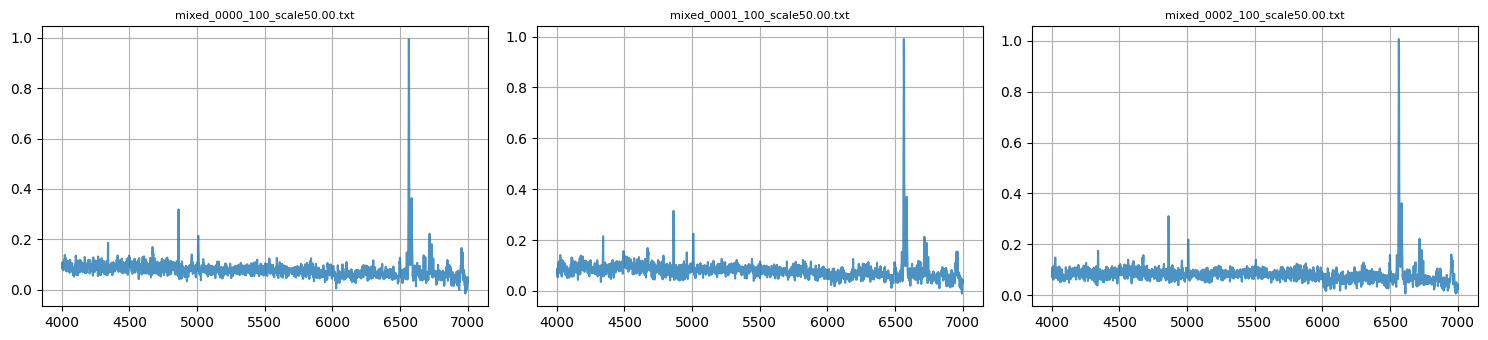

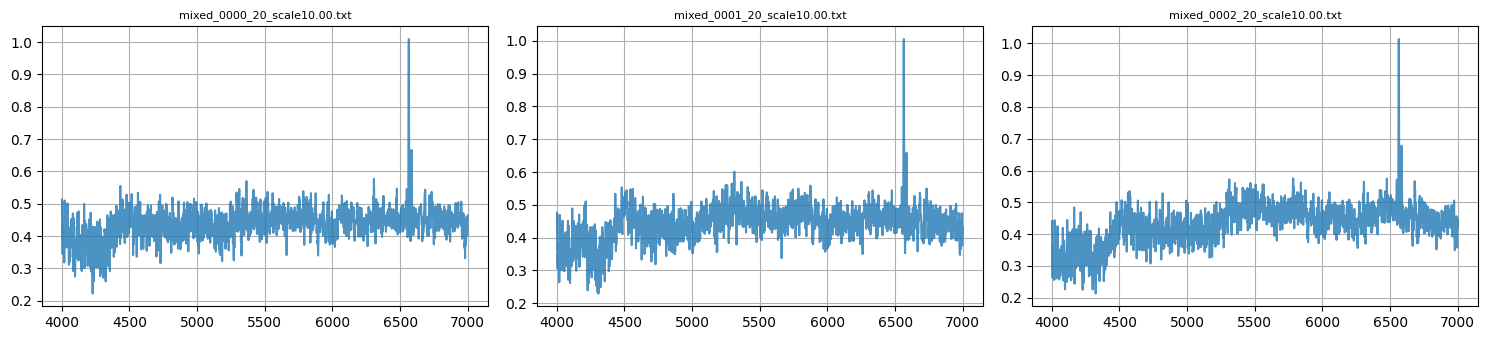

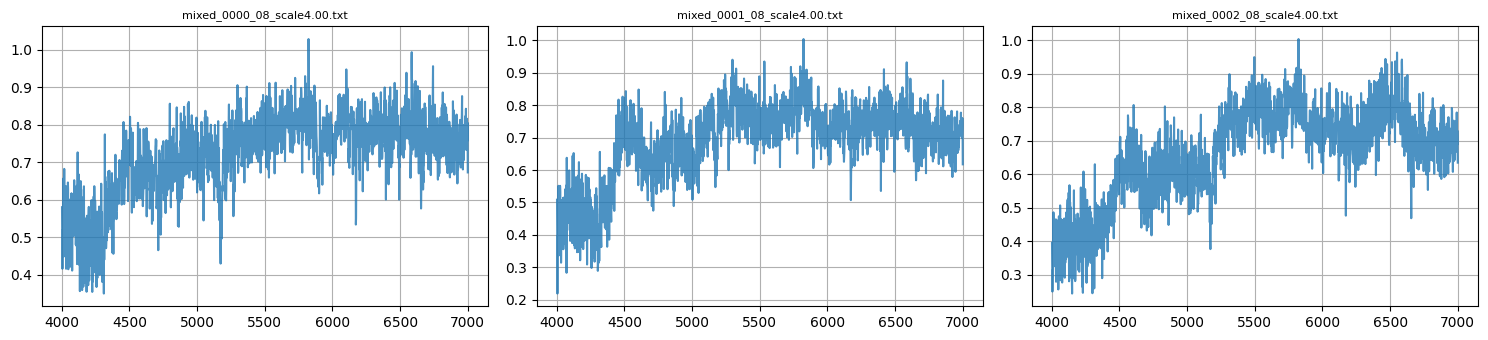

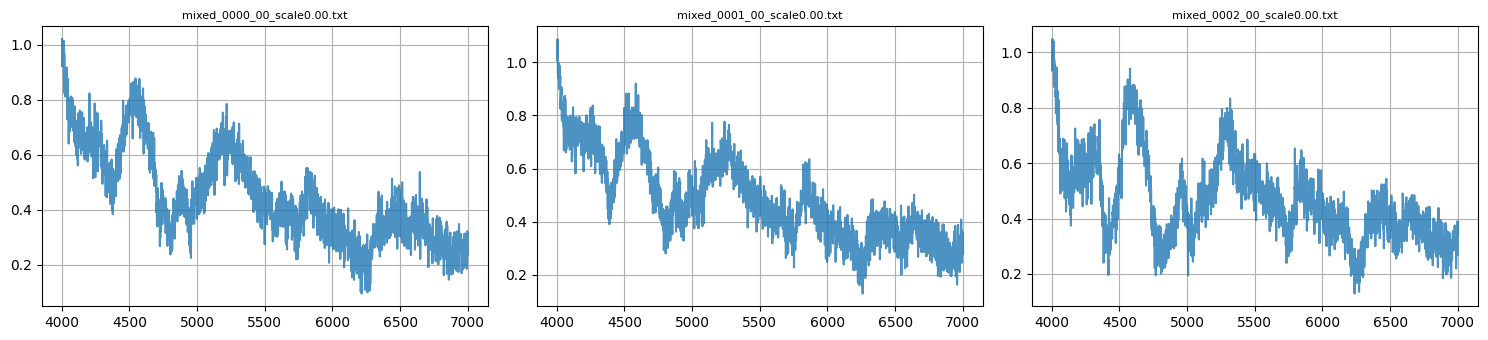

In [31]:
plot_spectra_from_folder("/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_test_28_test_noise/SN_Ia+SB",
                         file_exts=[".ascii",".flm",'.dat','e50.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_test_28_test_noise/SN_Ia+FL",
                         file_exts=[".ascii",".flm",'.dat','e10.00.txt'],
                         max_files=3,)


plot_spectra_from_folder("/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_test_28_test_noise/SN_Ia+FL",
                         file_exts=[".ascii",".flm",'.dat','e4.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_test_28_test_noise/SN_Ib+FL",
                         file_exts=[".ascii",".flm",'.dat','e0.00.txt'],
                         max_files=3,)

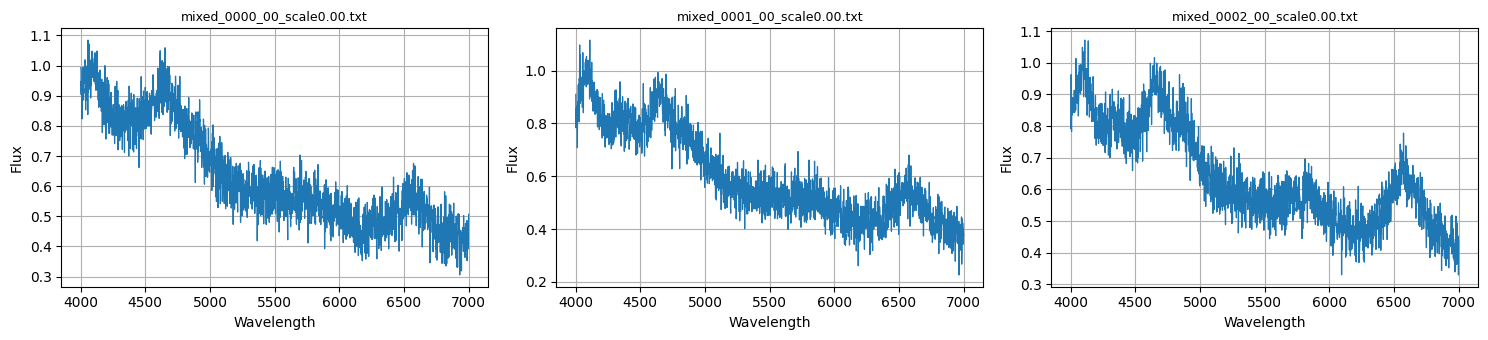

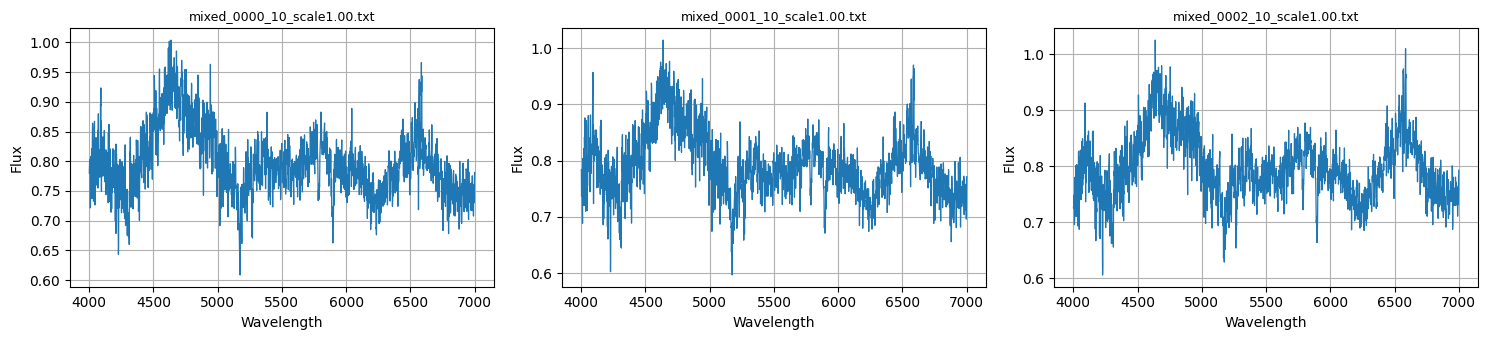

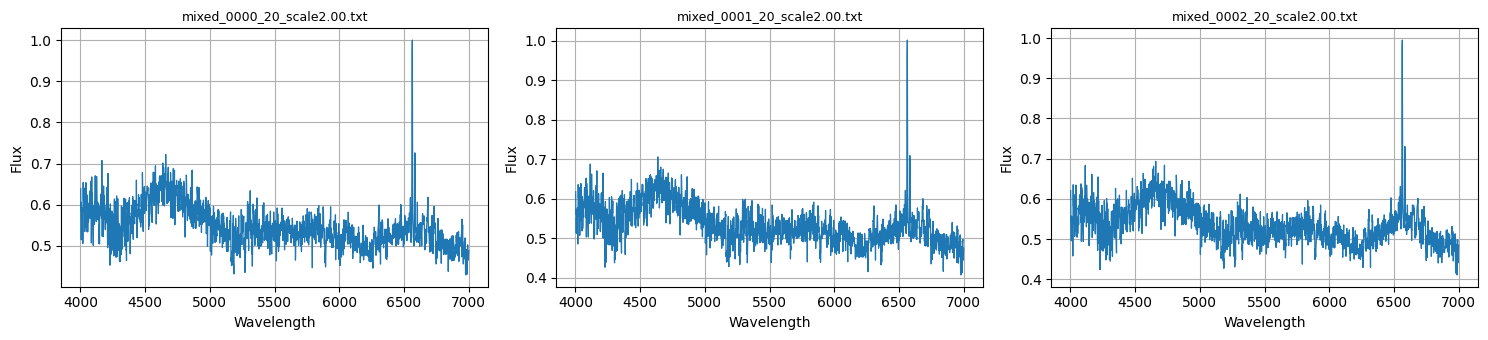

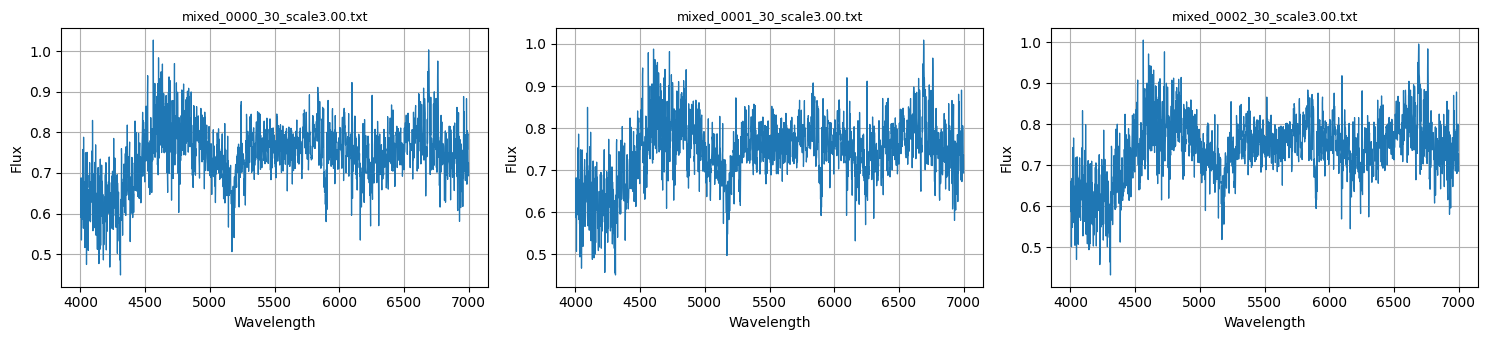

In [28]:
plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_23_noise/TDE_H+He+FL",
                         file_exts=[".ascii",".flm",'.dat','e0.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_23_noise/TDE_H+He+FL",
                         file_exts=[".ascii",".flm",'.dat','e1.00.txt'],
                         max_files=3,)


plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_23_noise/TDE_H+He+FL",
                         file_exts=[".ascii",".flm",'.dat','e2.00.txt'],
                         max_files=3,)

plot_spectra_from_folder("./Spectrum_moudel/bank/Mixed_Spectrum_test_23_noise/TDE_H+He+FL",
                         file_exts=[".ascii",".flm",'.dat','e3.00.txt'],
                         max_files=3,)

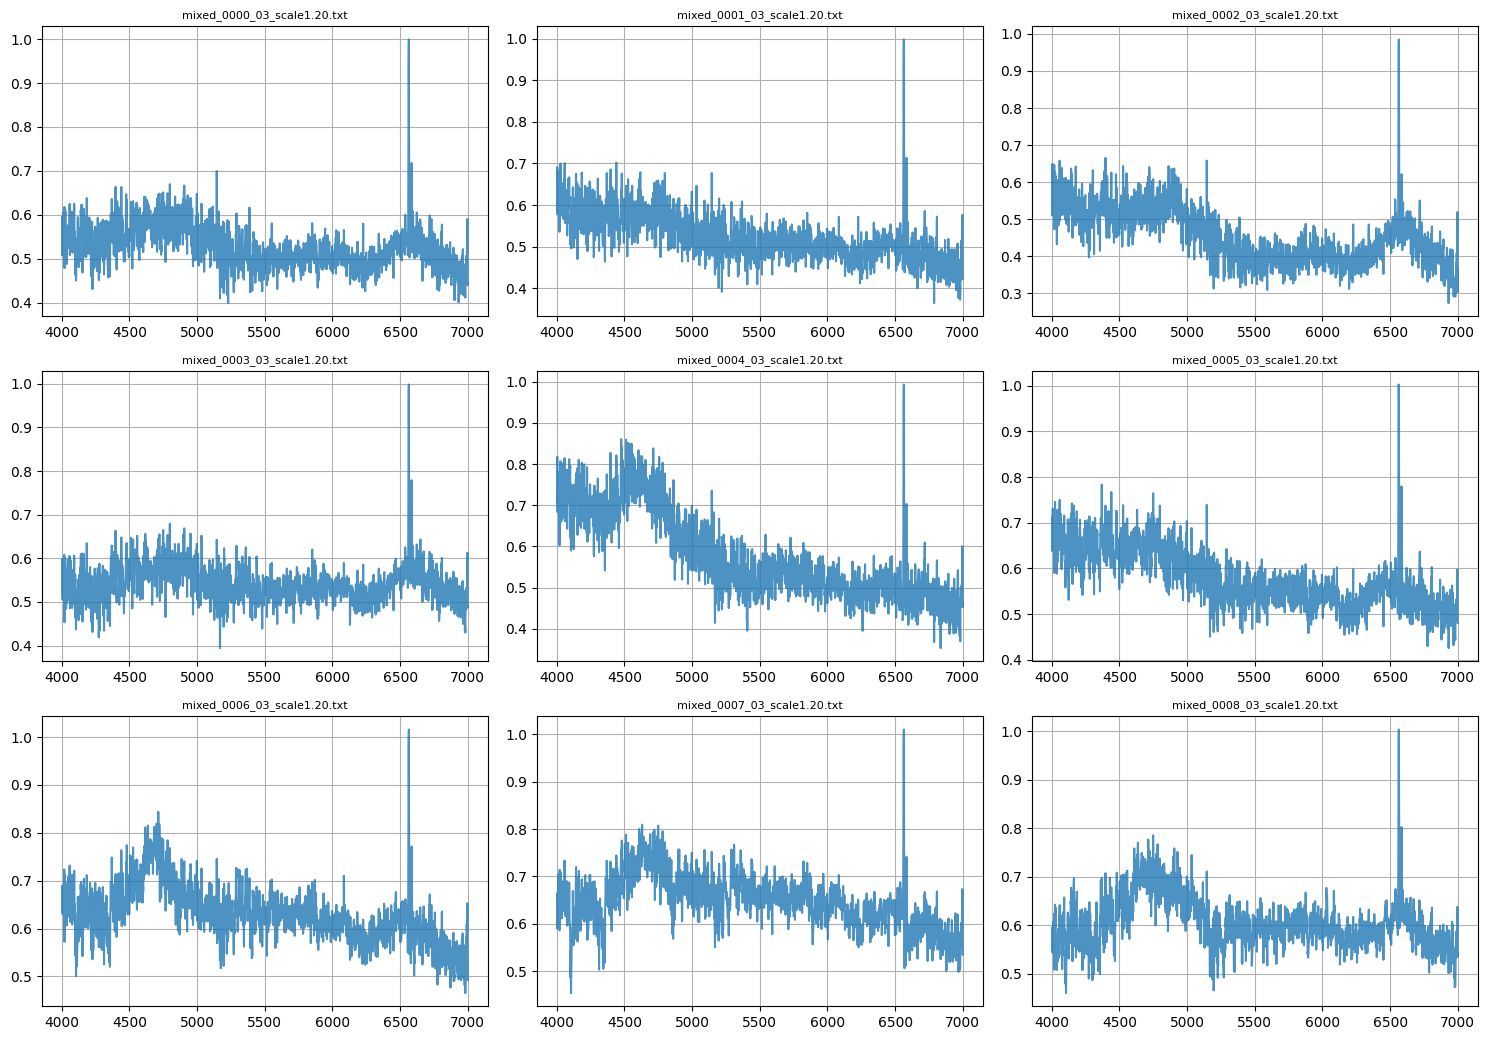

In [47]:
plot_spectra_from_folder("/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_test_21_noise_bac/TDE_H+FL",
                         file_exts=[".ascii",".flm",'.dat','e1.20.txt'],
                         max_files=29,)

#TDE H+He - mixed 0005 0013 0012
#TDE H - mixed 0009

## Generate PCA Train Data

In [1]:
import os
import numpy as np
import pandas as pd
import random
from scipy.interpolate import interp1d
from PCA_host_substract import fit_spectrum
from PCA_host_substract import fit_spectrum_with_sn_template


# Utility placeholders (to be defined by the user or mocked)
def is_ascii_file(filename):
    return filename.endswith(".txt")

def read_spectrum_file(filepath):
    data = np.loadtxt(filepath)
    wave = data[:, 0]
    flux = data[:, 1]
    return wave, flux
    
    
def iterative_polyfit(wave, flux, degree=3, sigma_clip=3.0, max_iter=5):
    """
    Iterative sigma-clipping continuum fit, automatically masking spectral lines.
    """
    mask = np.isfinite(flux)
    for _ in range(max_iter):
        coeffs = np.polyfit(wave[mask], flux[mask], degree)
        fit = np.polyval(coeffs, wave)
        residual = flux - fit
        std = np.std(residual[mask])
        new_mask = np.abs(residual) < sigma_clip * std
        if np.all(new_mask == mask):
            break
        mask = new_mask
        
    return np.polyval(coeffs, wave)


def linear_extrapolate_scalar(x, y, x_new):
    # x_new is a single scalar
    slope_start = (y[1]-y[0]) / (x[1]-x[0])
    slope_end   = (y[-1]-y[-2]) / (x[-1]-x[-2])
    
    if x_new == x[0]:
        return y[0]
    elif x_new == x[-1]:
        return y[-1]
    else:
        # If expansion to other points is needed, calculate using linear formula
        return None
    
def process_spectrum_to_3channel(flux_wave, flux_val,
                                 lambda_min=4000, lambda_max=7000,
                                 target_len=4000,
                                 degree=3, sigma_clip=3.0,
                                 apply_wavelet=True,
                                 wavelet='db4', level=2, threshold_scale=1.0,
                                 PCA_substract = False,
                                 filename=""):
    """
    Converts spectrum into (continuum_flux, line_flux) channels and aligns to a uniform wavelength grid.
    Optional wavelet denoising + maximum normalization.
    """
    
    valid =  np.isfinite(flux_val)
    if np.sum(valid) < 10:
        return np.zeros((target_len, 2), dtype=np.float32)

    wave = flux_wave[valid]
    flux = flux_val[valid]

    # Maximum normalization
    max_flux = np.max(flux)
    if max_flux <= 0 or np.isnan(max_flux):
        return np.zeros((target_len, 2), dtype=np.float32)
    norm_flux = flux / max_flux

    # Wavelet denoising (optional)
    if apply_wavelet:
        norm_flux = wavelet_denoise(norm_flux, wavelet=wavelet, level=level, threshold_scale=threshold_scale)
    
    if PCA_substract == True:
        # Set limit intervals
        lower_limit, upper_limit = 4000, 7000

        # Filter based on range
        mask = (wave >= lower_limit) & (wave <= upper_limit)
        wave = wave[mask]
        norm_flux = norm_flux[mask]

        # Update data
        data = [wave, norm_flux]
        
        host_template_path = '/home/zhengranfang/Second-Article/Train set/z_adjust/Galaxy_PCA_Train/pca_flux.txt'
        
        sn_Ia_path = "./Spectrum_moudel/PCA_moudel/pca_output_1/Ia-total/pca_flux.txt"
        sn_II_path = "./Spectrum_moudel/PCA_moudel/pca_output_1/II-total/pca_flux.txt"
        sn_IIn_path = "./Spectrum_moudel/PCA_moudel/pca_output_1/IIn/pca_flux.txt"
        sn_IIb_path = "./Spectrum_moudel/PCA_moudel/pca_output_1/IIb/pca_flux.txt"
        sn_Ib_path = "./Spectrum_moudel/PCA_moudel/pca_output_1/Ib-total/pca_flux.txt"
        sn_Ic_path = "./Spectrum_moudel/PCA_moudel/pca_output_1/Ic-total/pca_flux.txt"
        sn_TDE_path = "./Spectrum_moudel/PCA_moudel/pca_output_1/TDE/pca_flux.txt"
        
        sn_star_path = "/home/zhengranfang/Second-Article/Train set/z_adjust/Star_PCA_Train/pca_flux.txt"
        Total_path  = "/home/zhengranfang/Second-Article/Train set/z_adjust/PCA_Total/pca_flux.txt"
        
        # Fit with templates
        coeffs_Total, fit_model, residual, residual_rms_IIb, sn_model = fit_spectrum_with_sn_template(
            data,
            host_template_path,
            sn_template_path=Total_path,
            sn_n_components=20,
           
            denoise=True,
            visualize=False,
            plot_sn_component=True,   # Toggle: whether to plot transient components
            wavelet="db4"
        )
        
        coeffs_star, fit_model, residual, residual_rms_star, sn_model = fit_spectrum_with_sn_template(
            data,
            host_template_path,
            sn_template_path=sn_star_path,
            sn_n_components=20,
            transient_only=True,
            denoise=True,
            visualize=False,
            plot_sn_component=True, 
            wavelet="db4"
        )
        
    return np.stack([coeffs_Total,coeffs_star])
    

def visualize_bad_spectrum(wave, flux, path, reason, label):
    print(f"Visual Debug [{reason}] - {path} | Label: {label}")


def process_folders(
    folder_label_dict,
    output_len=2000,
    lambda_min=4000,
    lambda_max=7000,
    balance_by_label=True,
    max_per_label=np.inf,
    max_per_label_dict=None,
    visual_debug=False,
    scale_range=(0.0, 5.0),
    scale_range_dict=None,
    filter_by_scale=True,
    handle_subtypes=True,
    stratify_by_scale=True,    # Stratify by scale
    scale_bins=None,           # Custom bin boundaries, e.g., [0,1,2,5]
    bin_ratios=None,           # Ratio for each bin, e.g., [0.4,0.3,0.3]
    default_num_bins=5,        # Default number of bins for auto-binning
    noscale_handling='distribute'  # 'distribute'|'firstbin'|'all'|'ignore'
):
    """
    Improved process_folders: Supports scale range binning and handles files without scale information.
    noscale_handling:
      - 'distribute' (default): Assigns no-scale files to fill gaps in bins
      - 'firstbin': Places all no-scale files in the first bin
      - 'all': Treats no-scale files as global candidates (equivalent to no stratification)
      - 'ignore': Ignores files without scale information
    """
    X_data = []
    y_data = []

    for folder_path, label in folder_label_dict.items():
        print(f"\n📂 Scanning folder: {folder_path} (label={label})")

        # Get scale range for current folder
        folder_scale_range = scale_range_dict.get(folder_path, scale_range) if scale_range_dict else scale_range
        print(f'  scale range = [{folder_scale_range[0]} - {folder_scale_range[1]}]')

        # Generate bins & ratios automatically if needed
        folder_bins = scale_bins
        folder_ratios = bin_ratios
        if stratify_by_scale:
            if folder_bins is None:
                folder_bins = np.linspace(folder_scale_range[0], folder_scale_range[1], default_num_bins + 1)
                print(f"  ⚠️ Auto-generated {default_num_bins} scale bins: {folder_bins}")
            if folder_ratios is None:
                folder_ratios = np.ones(len(folder_bins) - 1) / (len(folder_bins) - 1)
                print(f"  ⚠️ Auto-using uniform bin_ratios: {folder_ratios}")

            if len(folder_ratios) != len(folder_bins) - 1:
                raise ValueError("bin_ratios length must equal len(scale_bins)-1")

        # Initialize bin containers
        if stratify_by_scale:
            num_bins = len(folder_bins) - 1
            scale_buckets = {i: [] for i in range(num_bins)}
            noscale_bucket = []  # Stores paths of files without scale
        else:
            scale_buckets = {"all": []}
            noscale_bucket = []

        # Walk through files and assign to buckets
        for root, _, files in os.walk(folder_path):
            for file in files:
                if not is_ascii_file(file):
                    continue

                scale_val = None
                if "scale" in file:
                    try:
                        tail = file.split("scale")[-1]
                        tail = os.path.splitext(tail)[0]
                        scale_val = float(tail)
                    except:
                        scale_val = None

                # Filter by scale range
                if filter_by_scale and (scale_val is not None):
                    if not (folder_scale_range[0] <= scale_val <= folder_scale_range[1]):
                        continue

                spectrum_path = os.path.join(root, file)
                if not os.path.isfile(spectrum_path):
                    continue

                if stratify_by_scale:
                    if scale_val is None:
                        noscale_bucket.append(spectrum_path)
                    else:
                        # Find assigned bin
                        bin_idx = np.digitize([scale_val], folder_bins) - 1
                        bin_idx = int(bin_idx[0])
                        bin_idx = max(0, min(bin_idx, num_bins - 1))
                        scale_buckets[bin_idx].append(spectrum_path)
                else:
                    scale_buckets["all"].append(spectrum_path)

        # Print distribution status
        if stratify_by_scale:
            for i in range(num_bins):
                print(f"  🔹 bin {i} [{folder_bins[i]:.3f}, {folder_bins[i+1]:.3f}): {len(scale_buckets[i])} files")
            print(f"  🔹 noscale (no 'scale' in name): {len(noscale_bucket)} files")
        else:
            print(f"  🔹 all scales: {len(scale_buckets.get('all', []))} files")

        # Sampling logic: sample per bin ratio, use noscale to fill gaps
        limit = max_per_label_dict[label] if (max_per_label_dict and label in max_per_label_dict) else max_per_label

        selected_paths = []
        if balance_by_label and np.isfinite(limit):
            if stratify_by_scale:
                # 1) Calculate target count per bin
                desired = np.floor(np.array(folder_ratios) * limit).astype(int)
                shortfall = int(limit - desired.sum())
                if shortfall > 0:
                    # Distribute remainder to bins with larger ratios
                    order = np.argsort(folder_ratios)[::-1]
                    idx = 0
                    while shortfall > 0:
                        desired[order[idx % len(order)]] += 1
                        shortfall -= 1
                        idx += 1

                # 2) Sample from each bin
                selected_per_bin = {i: [] for i in range(num_bins)}
                for i in range(num_bins):
                    paths = scale_buckets.get(i, [])
                    take_n = min(desired[i], len(paths))
                    if take_n > 0:
                        selected_per_bin[i] = random.sample(paths, take_n)
                    else:
                        selected_per_bin[i] = []

                # 3) Fill shortfall using no-scale bucket
                remaining_noscale = noscale_bucket.copy()
                for i in range(num_bins):
                    short = desired[i] - len(selected_per_bin[i])
                    if short > 0 and remaining_noscale:
                        take = min(short, len(remaining_noscale))
                        selected_per_bin[i].extend(remaining_noscale[:take])
                        remaining_noscale = remaining_noscale[take:]

                # 4) If still short, sample from remaining samples in all bins
                total_selected = sum(len(v) for v in selected_per_bin.values())
                if total_selected < limit:
                    remaining_candidates = []
                    for i in range(num_bins):
                        remaining_candidates.extend([p for p in scale_buckets[i] if p not in selected_per_bin[i]])
                    remaining_candidates.extend(remaining_noscale)
                    need = int(limit - total_selected)
                    if remaining_candidates:
                        take = min(need, len(remaining_candidates))
                        extra = random.sample(remaining_candidates, take)
                        idx = 0
                        for p in extra:
                            bin_idx = idx % num_bins
                            selected_per_bin[bin_idx].append(p)
                            idx += 1

                # 5) Aggregate paths
                for i in range(num_bins):
                    selected_paths.extend(selected_per_bin[i])

                print(f"  ✂️ Target limit={limit}, selected total {len(selected_paths)} (by bins + noscale fill).")
            else:
                # No stratification: direct random sampling
                all_paths = scale_buckets.get("all", [])
                take_n = min(int(limit), len(all_paths))
                selected_paths = random.sample(all_paths, take_n)
                print(f"  ✂️ Selected {take_n}/{len(all_paths)} from all scales.")
        else:
            # No limit or unbalanced: select all
            for paths in scale_buckets.values():
                selected_paths.extend(paths)
            if (noscale_handling == 'all') and noscale_bucket:
                selected_paths.extend(noscale_bucket)
            print(f"  ℹ️ No limit: {len(selected_paths)} files selected.")

        # Read and preprocess
        count_valid = 0
        for spectrum_path in selected_paths:
            wave, flux = read_spectrum_file(spectrum_path)
            if wave is None or flux is None:
                continue

            valid_flux = flux[flux != 0]
            median_flux = np.median(valid_flux) if len(valid_flux) > 0 else 0
            if median_flux == 0 or np.isnan(median_flux):
                continue
            
            if len(wave)<1000:
                continue

            processed = process_spectrum_to_3channel(
                wave, flux,
                target_len=output_len,
                filename=spectrum_path,
                apply_wavelet=True,
                PCA_substract=True
            )

            if np.all(processed == 0) or np.all(processed == processed[0]):
                if visual_debug:
                    visualize_bad_spectrum(wave, flux, spectrum_path, reason="Zero or constant output", label=label)
                continue

            X_data.append(processed)
            y_data.append(label)
            count_valid += 1

        print(f"✅ Valid samples collected for label {label}: {count_valid}")

    return np.array(X_data), np.array(y_data)


def save_to_output_dir(X_data, y_data, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    np.save(os.path.join(output_dir, 'X_test.npy'), X_data)
    np.save(os.path.join(output_dir, 'y_test.npy'), y_data)
    print(f"\n✅ Saved {len(X_data)} samples to {output_dir}")
    print(f"  ↳ X shape: {X_data.shape}")
    print(f"  ↳ y shape: {y_data.shape}")

For Real Running

A1 = { 

        "/home/zhengranfang/Second-Article/New_Class_1/Galaxy/Featureless":5,
        "/home/zhengranfang/Second-Article/New_Class_1/Galaxy/STARBURST":5,
        "/home/zhengranfang/Second-Article/New_Class_1/Galaxy/STARFORMING":5,
        "/home/zhengranfang/Second-Article/New_Class_1/Galaxy/AGN":5,
        "/home/zhengranfang/Second-Article/New_Class_1/Galaxy/AGN BROADLINE":5,
        "/home/zhengranfang/Second-Article/Processed_Star_txt":6,
        
        }
        
For Train Set

A2 = { 

        "./Train set/Galaxy/Featureless":5,
        "./Train set/Galaxy/STARBURST":5,
        "./Train set/Galaxy/STARFORMING":5,
        "./Train set/Galaxy/AGN":5,
        "./Train set/Galaxy/AGN BROADLINE":5,
        "./Train set/Star":6,
        
        }


For Test Set

A3 = { 

        "./Test set/Galaxy/Featureless":5,
        "./Test set/Galaxy/STARBURST":5,
        "./Test set/Galaxy/STARFORMING":5,
        "./Test set/Galaxy/AGN":5,
        "./Test set/Galaxy/AGN BROADLINE":5,
        "./Test set/Star":6,
        
        }
     

In [27]:
if __name__ == "__main__":
    
    #here bath is wrong, base is right
    bath_path = '/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/'
    
    #bath_path = '/share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_test_21_noise_bac/'
    
    
    folders_with_labels = {
        
        bath_path+"TDE_H+FL":0,
        bath_path+"TDE_H+SF":0,
        bath_path+"TDE_H+SB":0,
        bath_path+"TDE_He+FL":0,
        bath_path+"TDE_He+SF":0,
        bath_path+"TDE_He+SB":0,
        bath_path+"TDE_H+He+FL":0,
        bath_path+"TDE_H+He+SF":0,
        bath_path+"TDE_H+He+SB":0,
        
        bath_path+"SN_Ia+FL":1,
        bath_path+"SN_Ia+SF":1,
        bath_path+"SN_Ia+SB":1,
        
        bath_path+"SN_Ia_91bg+FL":1,
        bath_path+"SN_Ia_91bg+SF":1,
        bath_path+"SN_Ia_91bg+SB":1,
        
        bath_path+"SN_Ia_91T+FL":1,
        bath_path+"SN_Ia_91T+SF":1,
        bath_path+"SN_Ia_91T+SB":1,
        
        bath_path+"SN_Ia_99aa+FL":1,
        bath_path+"SN_Ia_99aa+SF":1,
        bath_path+"SN_Ia_99aa+SB":1,
        
        bath_path+"SN_Ia_02cx+FL":1,
        bath_path+"SN_Ia_02cx+SF":1,
        bath_path+"SN_Ia_02cx+SB":1,
        
        bath_path+"SN_Ib+FL":2,
        bath_path+"SN_Ib+SF":2,
        bath_path+"SN_Ib+SB":2,
        
        bath_path+"SN_Ibn+FL":2,
        bath_path+"SN_Ibn+SF":2,
        bath_path+"SN_Ibn+SB":2,
        
        bath_path+"SN_Ic+FL":3,
        bath_path+"SN_Ic+SF":3,
        bath_path+"SN_Ic+SB":3,
        
        bath_path+"SN_II+FL":4,
        bath_path+"SN_II+SF":4,
        bath_path+"SN_II+SB":4,
        
        bath_path+"SN_IIb+FL":4,
        bath_path+"SN_IIb+SF":4,
        bath_path+"SN_IIb+SB":4,
        
        bath_path+"SN_IIn+FL":4,
        bath_path+"SN_IIn+SF":4,
        bath_path+"SN_IIn+SB":4,
        
        
        
        
        
        "./Test set/Galaxy/Featureless":5,
        "./Test set/Galaxy/STARBURST":5,
        "./Test set/Galaxy/STARFORMING":5,
        "./Test set/Galaxy/AGN":5,
        "./Test set/Galaxy/AGN BROADLINE":5,
        "./Test set/Star":6,
      
     
        
    }
    
    scale_range_dict = {
        
        bath_path+"TDE_H+FL":(0,1.5),
        bath_path+"TDE_H+SF":(0,2),
        bath_path+"TDE_H+SB":(0,2),
        bath_path+"TDE_He+FL":(0,1.5),
        bath_path+"TDE_He+SF":(0,2),
        bath_path+"TDE_He+SB":(0,2),
        bath_path+"TDE_H+He+FL":(0,1.5),
        bath_path+"TDE_H+He+SF":(0,2),
        bath_path+"TDE_H+He+SB":(0,2),
        
        bath_path+"SN_Ia+FL":(0,2),                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
        bath_path+"SN_Ia+SF":(0,10),
        bath_path+"SN_Ia+SB":(0,10),
        
        bath_path+"SN_Ia_91bg+FL":(0,2),
        bath_path+"SN_Ia_91bg+SF":(0,10),
        bath_path+"SN_Ia_91bg+SB":(0,10),
        
        bath_path+"SN_Ia_91T+FL":(0,2),
        bath_path+"SN_Ia_91T+SF":(0,10),
        bath_path+"SN_Ia_91T+SB":(0,10),
        
        bath_path+"SN_Ia_99aa+FL":(0,2),
        bath_path+"SN_Ia_99aa+SF":(0,10),
        bath_path+"SN_Ia_99aa+SB":(0,10),
        
        bath_path+"SN_Ia_02cx+FL":(0,2),
        bath_path+"SN_Ia_02cx+SF":(0,10),
        bath_path+"SN_Ia_02cx+SB":(0,10),
        
        bath_path+"SN_Ib+FL":(0,2),
        bath_path+"SN_Ib+SF":(0,10),
        bath_path+"SN_Ib+SB":(0,10),
        
        bath_path+"SN_Ibn+FL":(0,2),         
        bath_path+"SN_Ibn+SF":(0,10),         
        bath_path+"SN_Ibn+SB":(0,10),
        
        bath_path+"SN_Ic+FL":(0,2),
        bath_path+"SN_Ic+SF":(0,10),
        bath_path+"SN_Ic+SB":(0,10),
        
        bath_path+"SN_II+FL":(0,2),
        bath_path+"SN_II+SF":(0,10),
        bath_path+"SN_II+SB":(0,10),
        
        bath_path+"SN_IIb+FL":(0,2),
        bath_path+"SN_IIb+SF":(0,10),
        bath_path+"SN_IIb+SB":(0,10),
        
        #bath_path+"SN_IIn+FL":(0,5),
        #bath_path+"SN_IIn+SF":(0,5),
        #bath_path+"SN_IIn+SB":(0,5),
        
        
        
        
   
    }
    

    
    lambda_min = 4000
    lambda_max = 7000
    target_len = 4000
    
    output_dir = "/share/zhengranfang/Spectrum_moudel/Training_Set_7P_PCA_SNmod_mock_train"
    
    max_samples = {
    0: 500,  # TDE
    1: 500,  # SN Ia
    2: 500,  # SN Ib
    3: 500,  # SN Ic
    4: 500,  # SN II
    5: 4000,  # Galaxy
    6: 4000,  # star
    
    }
    
    
    X, y = process_folders(
        folder_label_dict=folders_with_labels,
        output_len=target_len,
        lambda_min=lambda_min,
        lambda_max=lambda_max,
        visual_debug=True,
        max_per_label_dict=max_samples,
        scale_range=(0.0, 3.0),
        scale_range_dict=scale_range_dict,
        bin_ratios = [0.4 ,0.4,0.2],
        default_num_bins=3,
        
    )

    save_to_output_dir(X, y, output_dir)



📂 Scanning folder: /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/TDE_H+FL (label=0)
  scale range = [0 - 1.5]
  ⚠️ Auto-generated 3 scale bins: [0.  0.5 1.  1.5]
  🔹 bin 0 [0.000, 0.500): 20 files
  🔹 bin 1 [0.500, 1.000): 20 files
  🔹 bin 2 [1.000, 1.500): 22 files
  🔹 noscale (no 'scale' in name): 0 files
  ✂️ Target limit=500, selected total 62 (by bins + noscale fill).
✅ Valid samples collected for label 0: 62

📂 Scanning folder: /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/TDE_H+SF (label=0)
  scale range = [0 - 2]
  ⚠️ Auto-generated 3 scale bins: [0.         0.66666667 1.33333333 2.        ]
  🔹 bin 0 [0.000, 0.667): 28 files
  🔹 bin 1 [0.667, 1.333): 26 files
  🔹 bin 2 [1.333, 2.000): 28 files
  🔹 noscale (no 'scale' in name): 0 files
  ✂️ Target limit=500, selected total 82 (by bins + noscale fill).
✅ Valid samples collected for label 0: 82

📂 Scanning folder: /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/TDE_H+SB (label=0)
  scale rang

✅ Valid samples collected for label 1: 105

📂 Scanning folder: /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/SN_Ia_99aa+FL (label=1)
  scale range = [0 - 2]
  ⚠️ Auto-generated 3 scale bins: [0.         0.66666667 1.33333333 2.        ]
  🔹 bin 0 [0.000, 0.667): 10 files
  🔹 bin 1 [0.667, 1.333): 5 files
  🔹 bin 2 [1.333, 2.000): 10 files
  🔹 noscale (no 'scale' in name): 0 files
  ✂️ Target limit=500, selected total 25 (by bins + noscale fill).
✅ Valid samples collected for label 1: 25

📂 Scanning folder: /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/SN_Ia_99aa+SF (label=1)
  scale range = [0 - 10]
  ⚠️ Auto-generated 3 scale bins: [ 0.          3.33333333  6.66666667 10.        ]
  🔹 bin 0 [0.000, 3.333): 35 files
  🔹 bin 1 [3.333, 6.667): 35 files
  🔹 bin 2 [6.667, 10.000): 35 files
  🔹 noscale (no 'scale' in name): 0 files
  ✂️ Target limit=500, selected total 105 (by bins + noscale fill).
✅ Valid samples collected for label 1: 105

📂 Scanning folder: /sha

  🔹 bin 0 [0.000, 3.333): 259 files
  🔹 bin 1 [3.333, 6.667): 259 files
  🔹 bin 2 [6.667, 10.000): 259 files
  🔹 noscale (no 'scale' in name): 0 files
  ✂️ Target limit=500, selected total 500 (by bins + noscale fill).
✅ Valid samples collected for label 4: 500

📂 Scanning folder: /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/SN_IIb+FL (label=4)
  scale range = [0 - 2]
  ⚠️ Auto-generated 3 scale bins: [0.         0.66666667 1.33333333 2.        ]
  🔹 bin 0 [0.000, 0.667): 42 files
  🔹 bin 1 [0.667, 1.333): 21 files
  🔹 bin 2 [1.333, 2.000): 42 files
  🔹 noscale (no 'scale' in name): 0 files
  ✂️ Target limit=500, selected total 105 (by bins + noscale fill).
✅ Valid samples collected for label 4: 105

📂 Scanning folder: /share/zhengranfang/Spectrum_moudel/Mixed_Spectrum_31_test/SN_IIb+SF (label=4)
  scale range = [0 - 10]
  ⚠️ Auto-generated 3 scale bins: [ 0.          3.33333333  6.66666667 10.        ]
  🔹 bin 0 [0.000, 3.333): 147 files
  🔹 bin 1 [3.333, 6.667): 147 fil

In [51]:
import numpy as np
from sklearn.model_selection import train_test_split
import os

def split_dataset(input_dir, output_dir, seed=42, test_ratio=0.5):
    
    X = np.load(os.path.join(input_dir, "X_train.npy"))
    y = np.load(os.path.join(input_dir, "y_train.npy"))

    print(f"🔹 Loaded X: {X.shape}, y: {y.shape}")

    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=seed, shuffle=True
    )

    
    os.makedirs(output_dir, exist_ok=True)

   
    np.save(os.path.join(output_dir, "X_train.npy"), X_train)
    np.save(os.path.join(output_dir, "y_train.npy"), y_train)
    np.save(os.path.join(output_dir, "X_test.npy"), X_test)
    np.save(os.path.join(output_dir, "y_test.npy"), y_test)

    print(f"✅ Saved new splits to {output_dir}")
    print(f"  ↳ X_train: {X_train.shape}, X_test: {X_test.shape}")


if __name__ == "__main__":
    input_dir = "/share/zhengranfang/Spectrum_moudel/Training_Set_52F_PCA_SNmod_mock"
    output_dir = "/share/zhengranfang/Spectrum_moudel/Training_Set_52F_PCA_SNmod_mock-1"
    split_dataset(input_dir, output_dir, seed=42, test_ratio=1/4)

🔹 Loaded X: (22380, 2, 106), y: (22380,)
✅ Saved new splits to /share/zhengranfang/Spectrum_moudel/Training_Set_52F_PCA_SNmod_mock-1
  ↳ X_train: (16785, 2, 106), X_test: (5595, 2, 106)
